In [1]:
import sys
from pathlib import Path
import json
from textwrap import wrap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.backends.backend_pdf import PdfPages

ROOT = Path("/Users/andreali/Documents/Subgraph_Federated_Learning/")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from andrea.multigraph_generation import TASKS

In [7]:
SELECT_SUBSET_PATH = "clustering"
SELECT_SUBSET = "selected_subset"

EXPERIMENT_LOG_FOLDER = "experiment_log.csv"
DATA_DIR = "clustering/cluster_generation_parameters.csv"

SELECTED_SUBSETS_CSV_PATH = Path(f"./{SELECT_SUBSET_PATH}/{SELECT_SUBSET}.csv")
selected_subset = pd.read_csv(SELECTED_SUBSETS_CSV_PATH)
print("Loaded selected pairs rows:", len(selected_subset))

exp_log = pd.read_csv(EXPERIMENT_LOG_FOLDER)
print("exp rows:", len(exp_log))

test_gen = pd.read_csv(DATA_DIR)
print("Loaded generation rows:", len(test_gen))

Loaded selected pairs rows: 1
exp rows: 75
Loaded generation rows: 170


## 1. Parsing and manifest helpers

In [8]:
def parse_json_list_safe(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return x
    return json.loads(x)


def parse_json_dict_safe(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return {}
    if isinstance(x, dict):
        return x
    return json.loads(x)


def resolve_project_path(path_like):
    p = Path(path_like)
    candidates = []
    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.extend(
            [
                p,
                Path.cwd() / p,
                ROOT / p,
            ]
        )
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    raise FileNotFoundError(f"Could not resolve path: {path_like}")


def _summary_to_mean(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip()
    if x in {"-", "", "NA"}:
        return np.nan

    import re

    m = re.match(r"^\s*([-+]?\d+(?:\.\d+)?)\s*%", x)
    if m:
        return float(m.group(1))

    m = re.match(r"^\s*([-+]?\d+(?:\.\d+)?)", x)
    if m:
        return float(m.group(1))

    return np.nan


def _effective_step(row):
    round_val = row["round"] if "round" in row.index else np.nan
    local_epoch_val = row["local_epoch"] if "local_epoch" in row.index else np.nan

    if pd.notna(round_val):
        return int(round_val)

    if pd.notna(local_epoch_val):
        return int(local_epoch_val)

    return np.nan


def _split_pipe_values(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    out = []
    for part in str(x).split("|"):
        s = str(part).strip()
        if s == "" or s.lower() == "nan":
            continue
        try:
            f = float(s)
            if float(f).is_integer():
                s = str(int(f))
        except Exception:
            pass
        out.append(s)
    return out


def _members_to_multiline(member_str, per_line=6):
    gids = _split_pipe_values(member_str)
    if not gids:
        return "-"
    lines = []
    for i in range(0, len(gids), per_line):
        lines.append(", ".join(gids[i : i + per_line]))
    return "\n".join(lines)

In [9]:
METHOD_ORDER = ["fedavg", "fedprox", "gcfl_plus"]

METHOD_LABELS = {
    "fedavg": "FedAvg",
    "fedprox": "FedProx",
    "gcfl_plus": "GCFL+",
}

FAMILY_ORDER = [
    "strong_decreasing",
    "mild_decreasing",
    "flat_balanced",
    "mild_increasing",
    "strong_increasing",
]



def load_run_csv(csv_path_like) -> pd.DataFrame:
    csv_path = resolve_project_path(csv_path_like)
    return pd.read_csv(csv_path)


def filter_local_manifest(
    exp_log, subset_clients, model_tag, graph_ids=None, local_epochs=1
):
    part = exp_log[exp_log["run_type"] == "local"].copy()
    part = part[
        (part["subset_clients"] == str(subset_clients))
        & (part["model_tag"] == model_tag)
        & (pd.to_numeric(part["local_epochs"], errors="coerce") == int(local_epochs))
    ].copy()

    if graph_ids is not None:
        graph_ids = {str(g) for g in graph_ids}
        part = part[part["graph_id"].astype(str).isin(graph_ids)].copy()

    part["seed"] = pd.to_numeric(part["seed"], errors="coerce").astype("Int64")
    return part.sort_values(["seed", "graph_id"]).reset_index(drop=True)


def filter_method_manifest(exp_log, subset_clients, model_tag, method, local_epochs=1):
    part = exp_log[exp_log["run_type"] == method].copy()
    part = part[
        (part["subset_clients"] == str(subset_clients))
        & (part["model_tag"] == model_tag)
        & (pd.to_numeric(part["local_epochs"], errors="coerce") == int(local_epochs))
    ].copy()

    part["seed"] = pd.to_numeric(part["seed"], errors="coerce").astype("Int64")
    return part.sort_values(["seed"]).reset_index(drop=True)


def load_local_items(local_rows):
    items = []
    for _, row in local_rows.iterrows():
        items.append(
            {
                "seed": int(row["seed"]),
                "graph_id": str(row["graph_id"]),
                "family": row.get("family", None),
                "local_epochs": int(row["local_epochs"]),
                "df": load_run_csv(row["out_csv"]),
            }
        )
    return items


def load_method_items(method_rows):
    items = []
    for _, row in method_rows.iterrows():
        item = {
            "seed": int(row["seed"]),
            "local_epochs": int(row["local_epochs"]),
            "method": str(row["run_type"]),
            "df": load_run_csv(row["out_csv"]),
        }

        # keep GCFL+ metadata on the item so later plotting code can use it
        for col in [
            "subset_clients",
            "model_tag",
            "warmup_rounds",
            "min_cluster_size",
            "min_child_size",
            "grad_seq_len",
            "eps1_quantile",
            "eps2_quantile",
            "clusters_csv_path",
        ]:
            if col in row.index and pd.notna(row[col]):
                item[col] = row[col]

        if (
            str(row["run_type"]) == "gcfl_plus"
            and "clusters_csv_path" in row.index
            and pd.notna(row["clusters_csv_path"])
        ):
            item["clusters_df"] = load_gcfl_cluster_csv(row["clusters_csv_path"])

        items.append(item)

    return items


def load_gcfl_cluster_csv(path_like) -> pd.DataFrame:
    return pd.read_csv(resolve_project_path(path_like))

In [10]:
def _methods_available_for_subset(
    exp_log, subset_clients, model_tag, methods, local_epochs=1
):
    ok = []
    for method in methods:
        part = filter_method_manifest(
            exp_log,
            subset_clients=subset_clients,
            model_tag=model_tag,
            method=method,
            local_epochs=local_epochs,
        )
        if len(part) > 0:
            ok.append(method)
    return ok


HETEROGENEITY_COLS = [
    "task_profile_jsd_mean",
    "task_profile_jsd_median",
    "task_profile_jsd_max",
    "between_family_centroid_jsd_mean",
] + [f"{task}_pos_rate_std_across_clients" for task in TASKS]


def _subset_heterogeneity_payload(sel_row):
    out = {}
    for col in HETEROGENEITY_COLS:
        if col in sel_row.index and pd.notna(sel_row[col]):
            out[col] = float(sel_row[col])
    return out


def build_global_run_table(
    selected_subset_df, exp_log, methods=METHOD_ORDER, local_epochs=1
):
    rows = []

    for _, sel_row in selected_subset_df.iterrows():
        subset_clients = str(sel_row["subset_clients"])
        graph_ids = [str(x) for x in parse_json_list_safe(sel_row["graph_ids_json"])]
        family_order = parse_json_list_safe(sel_row["family_order_json"])
        family_to_graph_ids = {
            str(k): [str(v) for v in vals]
            for k, vals in parse_json_dict_safe(
                sel_row["family_to_graph_ids_json"]
            ).items()
        }
        family_counts = parse_json_dict_safe(sel_row["family_counts_json"])

        candidate_models = sorted(exp_log["model_tag"].dropna().astype(str).unique())

        for model_tag in candidate_models:
            local_rows = filter_local_manifest(
                exp_log,
                subset_clients=subset_clients,
                model_tag=model_tag,
                graph_ids=graph_ids,
                local_epochs=local_epochs,
            )
            if len(local_rows) == 0:
                continue

            available_methods = _methods_available_for_subset(
                exp_log,
                subset_clients=subset_clients,
                model_tag=model_tag,
                methods=methods,
                local_epochs=local_epochs,
            )
            if len(available_methods) == 0:
                continue

            rows.append(
                {
                    "subset_id": sel_row.get("subset_id", None),
                    "subset_clients": subset_clients,
                    "subset_size": int(sel_row.get("subset_size", len(graph_ids))),
                    "graph_ids": graph_ids,
                    "family_order": (
                        family_order if len(family_order) > 0 else FAMILY_ORDER
                    ),
                    "family_to_graph_ids": family_to_graph_ids,
                    "family_counts": family_counts,
                    "model_tag": model_tag,
                    "local_epochs": int(local_epochs),
                    "methods": available_methods,
                    **_subset_heterogeneity_payload(sel_row),
                }
            )

    return pd.DataFrame(rows)


def build_family_run_table(
    selected_subset_df, exp_log, methods=METHOD_ORDER, local_epochs=1
):
    rows = []

    for _, sel_row in selected_subset_df.iterrows():
        subset_clients = str(sel_row["subset_clients"])
        family_order = parse_json_list_safe(sel_row["family_order_json"])
        family_to_graph_ids = {
            str(k): [str(v) for v in vals]
            for k, vals in parse_json_dict_safe(
                sel_row["family_to_graph_ids_json"]
            ).items()
        }

        candidate_models = sorted(exp_log["model_tag"].dropna().astype(str).unique())

        for model_tag in candidate_models:
            available_methods = _methods_available_for_subset(
                exp_log,
                subset_clients=subset_clients,
                model_tag=model_tag,
                methods=methods,
                local_epochs=local_epochs,
            )
            if len(available_methods) == 0:
                continue

            ordered_families = family_order if len(family_order) > 0 else FAMILY_ORDER

            for fam_idx, family in enumerate(ordered_families):
                graph_ids = family_to_graph_ids.get(str(family), [])
                if not graph_ids:
                    continue

                rows.append(
                    {
                        "subset_id": sel_row.get("subset_id", None),
                        "subset_clients": subset_clients,
                        "family": str(family),
                        "family_order_idx": fam_idx,
                        "subset_size": len(graph_ids),
                        "graph_ids": [str(g) for g in graph_ids],
                        "model_tag": model_tag,
                        "local_epochs": int(local_epochs),
                        "methods": available_methods,
                        **_subset_heterogeneity_payload(sel_row),
                    }
                )

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["family_order_idx", "model_tag"]).reset_index(drop=True)
    return out


def build_client_run_table(
    selected_subset_df, exp_log, methods=METHOD_ORDER, local_epochs=1
):
    rows = []

    for _, sel_row in selected_subset_df.iterrows():
        subset_clients = str(sel_row["subset_clients"])
        family_order = parse_json_list_safe(sel_row["family_order_json"])
        family_to_graph_ids = {
            str(k): [str(v) for v in vals]
            for k, vals in parse_json_dict_safe(
                sel_row["family_to_graph_ids_json"]
            ).items()
        }
        graph_to_family = {
            str(k): str(v)
            for k, v in parse_json_dict_safe(sel_row["graph_to_family_json"]).items()
        }

        candidate_models = sorted(exp_log["model_tag"].dropna().astype(str).unique())

        for model_tag in candidate_models:
            available_methods = _methods_available_for_subset(
                exp_log,
                subset_clients=subset_clients,
                model_tag=model_tag,
                methods=methods,
                local_epochs=local_epochs,
            )
            if len(available_methods) == 0:
                continue

            ordered_families = family_order if len(family_order) > 0 else FAMILY_ORDER

            for fam_idx, family in enumerate(ordered_families):
                ordered_graph_ids = [
                    str(g) for g in family_to_graph_ids.get(str(family), [])
                ]

                for graph_idx, graph_id in enumerate(ordered_graph_ids):
                    rows.append(
                        {
                            "subset_id": sel_row.get("subset_id", None),
                            "subset_clients": subset_clients,
                            "family": graph_to_family.get(str(graph_id), str(family)),
                            "family_order_idx": fam_idx,
                            "graph_order_idx": graph_idx,
                            "graph_id": str(graph_id),
                            "model_tag": model_tag,
                            "local_epochs": int(local_epochs),
                            "methods": available_methods,
                            **_subset_heterogeneity_payload(sel_row),
                        }
                    )

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(
            ["family_order_idx", "graph_order_idx", "model_tag"]
        ).reset_index(drop=True)
    return out

In [11]:
def get_group_pooled_task_f1_postagg(
    *,
    method_items,
    task,
    graph_ids,
    split="val",
):
    target_graph_ids = [str(g) for g in graph_ids]
    curves = []

    for item in method_items:
        count_curves = []
        df = item["df"]

        for gid in target_graph_ids:
            count_curve = get_task_count_curve(
                df,
                phase="global_val_client_task",
                split=split,
                task=task,
                graph_id=gid,
            )
            count_curves.append(count_curve)

        pooled = _pool_count_curves(count_curves)
        if pooled.empty:
            continue

        tp = pooled["tp"].to_numpy(dtype=float)
        fp = pooled["fp"].to_numpy(dtype=float)
        fn = pooled["fn"].to_numpy(dtype=float)
        pooled["pooled_f1"] = binary_f1_from_counts(tp, fp, fn)
        curves.append(pooled[["step", "pooled_f1"]])

    return aggregate_seed_curves(curves, "pooled_f1")


def _pooled_micro_macro_from_task_counts_df(task_counts_df):
    if task_counts_df is None or task_counts_df.empty:
        return pd.DataFrame(columns=["step", "micro_f1", "macro_f1"])

    df = task_counts_df.copy()
    for c in ["tp", "fp", "tn", "fn"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["step"] = pd.to_numeric(df["step"], errors="coerce")
    df = df.dropna(subset=["step", "task", "tp", "fp", "tn", "fn"]).copy()
    if df.empty:
        return pd.DataFrame(columns=["step", "micro_f1", "macro_f1"])

    df["step"] = df["step"].astype(int)

    by_task = (
        df.groupby(["step", "task"], as_index=False)[["tp", "fp", "tn", "fn"]]
        .sum()
        .sort_values(["step", "task"])
        .reset_index(drop=True)
    )

    by_task["task_f1"] = binary_f1_from_counts(
        by_task["tp"].to_numpy(dtype=float),
        by_task["fp"].to_numpy(dtype=float),
        by_task["fn"].to_numpy(dtype=float),
    )

    macro_df = (
        by_task.groupby("step", as_index=False)["task_f1"]
        .mean()
        .rename(columns={"task_f1": "macro_f1"})
    )

    micro_counts = (
        by_task.groupby("step", as_index=False)[["tp", "fp", "fn"]]
        .sum()
        .sort_values("step")
        .reset_index(drop=True)
    )
    micro_counts["micro_f1"] = binary_f1_from_counts(
        micro_counts["tp"].to_numpy(dtype=float),
        micro_counts["fp"].to_numpy(dtype=float),
        micro_counts["fn"].to_numpy(dtype=float),
    )

    out = micro_counts[["step", "micro_f1"]].merge(
        macro_df[["step", "macro_f1"]],
        on="step",
        how="outer",
    )
    out = out.sort_values("step").reset_index(drop=True)
    return out


def _seed_local_task_counts_df(
    seed_local_items, graph_ids, split="val", phase="val_epoch_task"
):
    target_graph_ids = {str(g) for g in graph_ids}
    frames = []

    for task in TASKS:
        count_curves = []
        for item in seed_local_items:
            if str(item["graph_id"]) not in target_graph_ids:
                continue

            count_curve = get_task_count_curve(
                item["df"],
                phase=phase,
                split=split,
                task=task,
                graph_id=None,
            )
            if not count_curve.empty:
                count_curves.append(count_curve)

        pooled = _pool_count_curves(count_curves)
        if pooled.empty:
            continue

        pooled = pooled.copy()
        pooled["task"] = task
        frames.append(pooled)

    if len(frames) == 0:
        return pd.DataFrame(columns=["step", "task", "tp", "fp", "tn", "fn"])

    return pd.concat(frames, axis=0, ignore_index=True)


def _seed_method_task_counts_df(
    method_item, graph_ids, *, split="val", phase="global_val_client_task"
):
    target_graph_ids = [str(g) for g in graph_ids]
    frames = []
    df = method_item["df"]

    for task in TASKS:
        count_curves = []
        for gid in target_graph_ids:
            count_curve = get_task_count_curve(
                df,
                phase=phase,
                split=split,
                task=task,
                graph_id=gid,
            )
            if not count_curve.empty:
                count_curves.append(count_curve)

        pooled = _pool_count_curves(count_curves)
        if pooled.empty:
            continue

        pooled = pooled.copy()
        pooled["task"] = task
        frames.append(pooled)

    if len(frames) == 0:
        return pd.DataFrame(columns=["step", "task", "tp", "fp", "tn", "fn"])

    return pd.concat(frames, axis=0, ignore_index=True)


def _seed_local_pooled_micro_macro_curve(
    seed_local_items, graph_ids, split="val", phase="val_epoch_task"
):
    task_counts_df = _seed_local_task_counts_df(
        seed_local_items,
        graph_ids,
        split=split,
        phase=phase,
    )
    return _pooled_micro_macro_from_task_counts_df(task_counts_df)


def _seed_method_pooled_micro_macro_curve(
    method_item, graph_ids, *, split="val", phase="global_val_client_task"
):
    task_counts_df = _seed_method_task_counts_df(
        method_item,
        graph_ids,
        split=split,
        phase=phase,
    )
    return _pooled_micro_macro_from_task_counts_df(task_counts_df)


def get_group_pooled_micro_macro_local(local_items, graph_ids, split="val"):
    micro_curves, macro_curves = [], []

    seeds = sorted({int(item["seed"]) for item in local_items})
    for seed in seeds:
        seed_local_items = [item for item in local_items if int(item["seed"]) == seed]
        pooled = _seed_local_pooled_micro_macro_curve(
            seed_local_items,
            graph_ids,
            split=split,
            phase="val_epoch_task",
        )
        if pooled.empty:
            continue

        micro_curves.append(pooled[["step", "micro_f1"]].copy())
        macro_curves.append(pooled[["step", "macro_f1"]].copy())

    return {
        "micro_f1": aggregate_seed_curves(micro_curves, "micro_f1"),
        "macro_f1": aggregate_seed_curves(macro_curves, "macro_f1"),
    }


def get_group_pooled_micro_macro_method(
    *,
    method_items,
    graph_ids,
    phase,
    split="val",
):
    micro_curves, macro_curves = [], []

    for item in method_items:
        pooled = _seed_method_pooled_micro_macro_curve(
            item,
            graph_ids,
            split=split,
            phase=phase,
        )
        if pooled.empty:
            continue

        micro_curves.append(pooled[["step", "micro_f1"]].copy())
        macro_curves.append(pooled[["step", "macro_f1"]].copy())

    return {
        "micro_f1": aggregate_seed_curves(micro_curves, "micro_f1"),
        "macro_f1": aggregate_seed_curves(macro_curves, "macro_f1"),
    }


def get_group_delta_local_minus_method_micro_macro(
    *,
    local_items,
    method_items,
    graph_ids,
    method_phase,
    split="val",
):
    method_by_seed = {int(item["seed"]): item for item in method_items}

    delta_micro_curves = []
    delta_macro_curves = []

    seeds = sorted({int(item["seed"]) for item in local_items})
    for seed in seeds:
        if seed not in method_by_seed:
            continue

        seed_local_items = [item for item in local_items if int(item["seed"]) == seed]

        local_curve = _seed_local_pooled_micro_macro_curve(
            seed_local_items,
            graph_ids,
            split=split,
            phase="val_epoch_task",
        )
        method_curve = _seed_method_pooled_micro_macro_curve(
            method_by_seed[seed],
            graph_ids,
            split=split,
            phase=method_phase,
        )

        if local_curve.empty or method_curve.empty:
            continue

        merged = local_curve.merge(
            method_curve,
            on="step",
            how="inner",
            suffixes=("_local", "_method"),
        )
        if merged.empty:
            continue

        delta_micro = merged[["step"]].copy()
        delta_micro["delta_micro_f1"] = (
            merged["micro_f1_local"] - merged["micro_f1_method"]
        )

        delta_macro = merged[["step"]].copy()
        delta_macro["delta_macro_f1"] = (
            merged["macro_f1_local"] - merged["macro_f1_method"]
        )

        delta_micro_curves.append(delta_micro)
        delta_macro_curves.append(delta_macro)

    return {
        "micro_f1": aggregate_seed_curves(delta_micro_curves, "delta_micro_f1"),
        "macro_f1": aggregate_seed_curves(delta_macro_curves, "delta_macro_f1"),
    }


def get_weighted_group_loss_for_method(
    *,
    method_items,
    phase,
    graph_ids,
    split="val",
):
    return get_weighted_group_scalar_stats(
        items=method_items,
        phase=phase,
        split=split,
        metric_col="eval_loss",
        graph_ids=graph_ids,
        use_graph_filter=True,
    )


def get_pooled_delta_local_minus_method(
    *,
    local_items,
    method_items,
    task,
    graph_ids,
    split="val",
):
    target_graph_ids = {str(g) for g in graph_ids}
    method_by_seed = {int(item["seed"]): item for item in method_items}
    delta_curves = []

    seeds = sorted({int(item["seed"]) for item in local_items})
    for seed in seeds:
        if seed not in method_by_seed:
            continue

        # pooled local
        local_count_curves = []
        seed_local_items = [
            item
            for item in local_items
            if int(item["seed"]) == seed and str(item["graph_id"]) in target_graph_ids
        ]
        for item in seed_local_items:
            count_curve = get_task_count_curve(
                item["df"],
                phase="val_epoch_task",
                split=split,
                task=task,
                graph_id=None,
            )
            local_count_curves.append(count_curve)

        pooled_local = _pool_count_curves(local_count_curves)
        if pooled_local.empty:
            continue
        pooled_local["pooled_f1"] = binary_f1_from_counts(
            pooled_local["tp"].to_numpy(dtype=float),
            pooled_local["fp"].to_numpy(dtype=float),
            pooled_local["fn"].to_numpy(dtype=float),
        )

        # pooled method postagg
        method_df = method_by_seed[seed]["df"]
        method_count_curves = []
        for gid in target_graph_ids:
            count_curve = get_task_count_curve(
                method_df,
                phase="global_val_client_task",
                split=split,
                task=task,
                graph_id=gid,
            )
            method_count_curves.append(count_curve)

        pooled_method = _pool_count_curves(method_count_curves)
        if pooled_method.empty:
            continue
        pooled_method["pooled_f1"] = binary_f1_from_counts(
            pooled_method["tp"].to_numpy(dtype=float),
            pooled_method["fp"].to_numpy(dtype=float),
            pooled_method["fn"].to_numpy(dtype=float),
        )

        merged = pd.merge(
            pooled_local[["step", "pooled_f1"]],
            pooled_method[["step", "pooled_f1"]],
            on="step",
            how="inner",
            suffixes=("_local", "_method"),
        )
        if merged.empty:
            continue

        merged["delta"] = merged["pooled_f1_local"] - merged["pooled_f1_method"]
        delta_curves.append(merged[["step", "delta"]])

    return aggregate_seed_curves(delta_curves, "delta")

In [12]:
def build_overview_global_title(row):
    return (
        f"Aggregated / pooled performance over {int(row['subset_size'])} clients"
        f" | model={row['model_tag']}"
    )


def build_overview_family_title(row):
    return (
        f"Family aggregated / pooled performance"
        f" | family={row['family']}"
        f" | n_clients={int(row['subset_size'])}"
        f" | model={row['model_tag']}"
    )


def build_method_global_title(method, row):
    return (
        f"{METHOD_LABELS[method]} diagnostics"
        f" | aggregated / pooled over {int(row['subset_size'])} clients"
        f" | model={row['model_tag']}"
    )


def build_method_family_title(method, row):
    return (
        f"{METHOD_LABELS[method]} diagnostics"
        f" | family={row['family']}"
        f" | n_clients={int(row['subset_size'])}"
        f" | model={row['model_tag']}"
    )


def build_gcfl_seed_title(row, seed_pack, section_title):
    return (
        f"GCFL+ diagnostics | aggregated / pooled over {int(row['subset_size'])} clients"
        f" | seed={int(seed_pack['seed'])} | {section_title}"
    )


def _compose_global_overview_header_text(row, test_gen):
    return _compose_header_text(_global_family_rate_text(row, test_gen), row)


def _compose_family_overview_header_text(row, test_gen):
    return _family_rate_text(row["graph_ids"], test_gen, family_name=row["family"])


def _compose_method_global_header_text(method, row, test_gen):
    return _compose_header_text(_global_family_rate_text(row, test_gen), row)


def _compose_method_family_header_text(method, row, test_gen):
    return _family_rate_text(row["graph_ids"], test_gen, family_name=row["family"])


def _compose_gcfl_seed_header_text(row, test_gen):
    base = _compose_header_text(_global_family_rate_text(row, test_gen), row)
    return f"model={row['model_tag']}\n{base}"

## 2. Curve utilities

In [13]:
def aggregate_seed_curves(curves, value_col):
    parts = []
    for seed_idx, curve in enumerate(curves):
        if curve is None or curve.empty:
            continue
        part = curve[["step", value_col]].dropna().copy()
        if part.empty:
            continue
        part["seed_idx"] = seed_idx
        parts.append(part)

    if not parts:
        return pd.DataFrame(columns=["step", "mean", "std", "count"])

    full = pd.concat(parts, axis=0, ignore_index=True)
    agg = (
        full.groupby("step")[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("step")
    )
    agg["std"] = agg["std"].fillna(0.0)
    return agg

def get_task_count_curve(
    df,
    *,
    phase,
    split,
    task,
    graph_id=None,
):
    part = df[
        (df["phase"] == phase) & (df["split"] == split) & (df["task"] == task)
    ].copy()

    if graph_id is not None and "graph_id" in part.columns:
        part = part[part["graph_id"].astype(str) == str(graph_id)].copy()

    needed = ["tp", "fp", "tn", "fn"]
    if part.empty or any(c not in part.columns for c in needed):
        return pd.DataFrame(columns=["step", "tp", "fp", "tn", "fn"])

    part["step"] = part.apply(_effective_step, axis=1)
    part = part[pd.notna(part["step"])].copy()
    if part.empty:
        return pd.DataFrame(columns=["step", "tp", "fp", "tn", "fn"])

    part["step"] = part["step"].astype(int)

    for c in needed:
        part[c] = pd.to_numeric(part[c], errors="coerce")

    part = part.dropna(subset=needed).copy()
    if part.empty:
        return pd.DataFrame(columns=["step", "tp", "fp", "tn", "fn"])

    out = (
        part.groupby("step", as_index=False)[needed]
        .sum()
        .sort_values("step")
        .reset_index(drop=True)
    )
    return out


def binary_f1_from_counts(tp, fp, fn):
    denom = 2.0 * tp + fp + fn
    out = np.full_like(tp, np.nan, dtype=float)
    valid = denom > 0
    out[valid] = (2.0 * tp[valid]) / denom[valid]
    return out


def plot_mean_std(
    ax,
    agg_df,
    *,
    label,
    linestyle="-",
    color=None,
    alpha_fill=0.16,
    linewidth=2.0,
):
    if agg_df is None or agg_df.empty:
        return False

    x = agg_df["step"].to_numpy()
    y = agg_df["mean"].to_numpy()
    s = agg_df["std"].to_numpy()

    (line,) = ax.plot(
        x,
        y,
        label=label,
        linestyle=linestyle,
        color=color,
        linewidth=linewidth,
    )
    fill_color = line.get_color()
    ax.fill_between(x, y - s, y + s, alpha=alpha_fill, color=fill_color)
    return True


def annotate_no_data(ax, text="No data"):
    ax.text(
        0.5,
        0.5,
        text,
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=10,
        color="gray",
    )

## 3. Group aggregation

In [14]:
def _detect_weight_col(df):
    candidates = ["num_nodes", "n_nodes", "node_count", "num_samples"]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        "Could not find a node-count column in the run CSV. "
        "Expected one of: num_nodes, n_nodes, node_count, num_samples"
    )


def get_weighted_group_scalar_stats(
    *,
    items,
    phase,
    split,
    metric_col,
    graph_ids=None,
    use_graph_filter=True,
):
    seed_curves = []

    for item in items:
        df = item["df"].copy()

        part = df[(df["phase"] == phase) & (df["split"] == split)].copy()
        if part.empty or metric_col not in part.columns:
            continue

        if use_graph_filter and graph_ids is not None and "graph_id" in part.columns:
            part = part[
                part["graph_id"].astype(str).isin([str(g) for g in graph_ids])
            ].copy()

        if part.empty:
            continue

        weight_col = _detect_weight_col(part)

        part["step"] = part.apply(_effective_step, axis=1)
        part = part[pd.notna(part["step"])].copy()
        if part.empty:
            continue

        part["step"] = part["step"].astype(int)

        part[metric_col] = pd.to_numeric(part[metric_col], errors="coerce")
        part[weight_col] = pd.to_numeric(part[weight_col], errors="coerce")

        part = part[
            pd.notna(part[metric_col])
            & pd.notna(part[weight_col])
            & (part[weight_col] > 0)
        ].copy()
        if part.empty:
            continue

        grouped = (
            part.groupby("step", as_index=False)
            .apply(
                lambda g: pd.Series(
                    {
                        metric_col: np.average(
                            g[metric_col].to_numpy(dtype=float),
                            weights=g[weight_col].to_numpy(dtype=float),
                        )
                    }
                )
            )
            .reset_index(drop=True)
            .sort_values("step")
        )

        if not grouped.empty:
            seed_curves.append(grouped[["step", metric_col]])

    return aggregate_seed_curves(seed_curves, metric_col)


def _pool_count_curves(curves):
    good = []
    for curve in curves:
        if curve is None or curve.empty:
            continue
        good.append(curve[["step", "tp", "fp", "tn", "fn"]].copy())

    if not good:
        return pd.DataFrame(columns=["step", "tp", "fp", "tn", "fn"])

    full = pd.concat(good, axis=0, ignore_index=True)
    pooled = (
        full.groupby("step")[["tp", "fp", "tn", "fn"]]
        .sum()
        .reset_index()
        .sort_values("step")
    )
    return pooled


def get_group_pooled_task_f1_local(
    *,
    local_items,
    task,
    graph_ids,
    split="val",
):
    target_graph_ids = {str(g) for g in graph_ids}
    curves = []

    seeds = sorted({int(item["seed"]) for item in local_items})

    for seed in seeds:
        count_curves = []
        seed_items = [
            item
            for item in local_items
            if int(item["seed"]) == seed and str(item["graph_id"]) in target_graph_ids
        ]

        for item in seed_items:
            count_curve = get_task_count_curve(
                item["df"],
                phase="val_epoch_task",
                split=split,
                task=task,
                graph_id=None,
            )
            count_curves.append(count_curve)

        pooled = _pool_count_curves(count_curves)
        if pooled.empty:
            continue

        tp = pooled["tp"].to_numpy(dtype=float)
        fp = pooled["fp"].to_numpy(dtype=float)
        fn = pooled["fn"].to_numpy(dtype=float)

        pooled["pooled_f1"] = binary_f1_from_counts(tp, fp, fn)
        curves.append(pooled[["step", "pooled_f1"]])

    return aggregate_seed_curves(curves, "pooled_f1")


def _rate_col_from_test_gen(task, test_gen):
    candidates = [
        f"train_{task}_pos_rate",
        f"val_{task}_pos_rate",
        f"test_{task}_pos_rate",
        f"p_{task}",
        task,
    ]
    for c in candidates:
        if c in test_gen.columns:
            return c
    raise KeyError(
        f"Could not find a rate column for task={task}. " f"Tried: {candidates}"
    )


def _graph_rate_text(graph_id, test_gen):
    part = test_gen[test_gen["graph_id"].astype(str) == str(graph_id)].copy()
    if part.empty:
        return f"graph_id={graph_id} | pos rates: unavailable"

    vals = []
    for task in TASKS:
        col = _rate_col_from_test_gen(task, test_gen)
        v = float(part.iloc[0][col])
        vals.append(f"{task}={100*v:.1f}%")

    return f"graph_id={graph_id} | " + " | ".join(vals)


def _family_rate_text(graph_ids, test_gen, family_name=None):
    part = test_gen[
        test_gen["graph_id"].astype(str).isin([str(g) for g in graph_ids])
    ].copy()
    if part.empty:
        prefix = f"family={family_name} | " if family_name is not None else ""
        return prefix + "pos rates: unavailable"

    vals = []
    for task in TASKS:
        col = _rate_col_from_test_gen(task, test_gen)
        arr = part[col].astype(float).to_numpy()
        vals.append(f"{task}={100*np.mean(arr):.1f}%±{100*np.std(arr):.1f}%")

    prefix = f"family={family_name} | " if family_name is not None else ""
    return prefix + " | ".join(vals)


def _global_family_rate_text(row, test_gen):
    lines = []
    fam_map = row["family_to_graph_ids"]
    fam_order = (
        row["family_order"] if len(row["family_order"]) > 0 else list(fam_map.keys())
    )

    for fam in fam_order:
        gids = fam_map[str(fam)]
        lines.append(_family_rate_text(gids, test_gen, family_name=str(fam)))

    return "\n".join(lines)


def _fmt_float(x, digits=3):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return "NA"
    return f"{float(x):.{digits}f}"


def _heterogeneity_text(row):
    main_bits = []
    for col, label in [
        ("task_profile_jsd_mean", "task_jsd_mean"),
        ("task_profile_jsd_median", "task_jsd_median"),
        ("task_profile_jsd_max", "task_jsd_max"),
        ("between_family_centroid_jsd_mean", "family_centroid_jsd_mean"),
    ]:
        if col in row and pd.notna(row[col]):
            main_bits.append(f"{label}={_fmt_float(row[col], 3)}")

    task_bits = []
    for task in TASKS:
        col = f"{task}_pos_rate_std_across_clients"
        if col in row and pd.notna(row[col]):
            task_bits.append(f"{task}_std={_fmt_float(row[col], 3)}")

    lines = []
    if len(main_bits) > 0:
        lines.append("heterogeneity | " + " | ".join(main_bits))
    if len(task_bits) > 0:
        lines.append("per-task pos-rate std | " + " | ".join(task_bits))

    return "\n".join(lines)


def _compose_header_text(base_text, row):
    het = _heterogeneity_text(row)
    if het.strip() == "":
        return base_text
    return f"{base_text}\n{het}"


def _header_top_from_text(text):
    n_lines = max(1, str(text).count("\n") + 1)
    return max(0.74, 0.92 - 0.022 * (n_lines - 1))


def _wrap_header_block(text: str, width: int = 125) -> str:
    if text is None:
        return ""

    lines = []
    for raw in str(text).split("\n"):
        raw = str(raw).strip()
        if raw == "":
            continue
        wrapped = wrap(
            raw,
            width=width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        if len(wrapped) == 0:
            lines.append(raw)
        else:
            lines.extend(wrapped)
    return "\n".join(lines)


def _wrap_header_block(text: str, width: int = 120) -> str:
    if text is None:
        return ""

    lines = []
    for raw in str(text).split("\n"):
        raw = str(raw).strip()
        if raw == "":
            continue
        wrapped = wrap(
            raw,
            width=width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        if len(wrapped) == 0:
            lines.append(raw)
        else:
            lines.extend(wrapped)
    return "\n".join(lines)


def _apply_page_header(fig, title, header_text):
    title_wrapped = "\n".join(
        wrap(
            str(title),
            width=78,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )
    header_wrapped = _wrap_header_block(header_text, width=128)

    n_title_lines = max(1, title_wrapped.count("\n") + 1)
    n_header_lines = max(1, header_wrapped.count("\n") + 1)

    # keep title near the top
    title_y = 0.982

    # move the header closer to the title
    header_y = 0.948 - 0.026 * (n_title_lines - 1)

    # place the subplot region just below the header block
    header_bottom = header_y - 0.020 * n_header_lines
    subplot_top = max(0.78, header_bottom - 0.015)

    fig.subplots_adjust(
        top=subplot_top,
        left=0.045,
        right=0.985,
        bottom=0.05,
    )

    fig.text(
        0.5,
        title_y,
        title_wrapped,
        ha="center",
        va="top",
        fontsize=13,
        fontweight="bold",
    )
    fig.text(
        0.5,
        header_y,
        header_wrapped,
        ha="center",
        va="top",
        fontsize=9.5,
    )


def _wrap_cell_text(val, width=28):
    s = "" if pd.isna(val) else str(val)
    s = s.replace("|", ", ")
    parts = wrap(
        s,
        width=width,
        break_long_words=False,
        break_on_hyphens=False,
    )
    return "\n".join(parts) if len(parts) > 0 else s


def _compact_gcfl_summary_df(summary_df: pd.DataFrame) -> pd.DataFrame:
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()

    rename_map = {
        "Seed": "Seed",
        "eps1 q": "eps1 q",
        "eps2 q": "eps2 q",
        "Warmup": "Warmup",
        "Hist len": "Hist",
        "Min cluster": "Min cl",
        "Min child": "Min ch",
        "Triggered rounds": "Triggered",
        "Applied rounds": "Applied",
        "Final active IDs": "Final IDs",
        "Final active sizes": "Final sizes",
    }
    out = summary_df.rename(columns=rename_map).copy()

    for c in ["Triggered", "Applied", "Final IDs", "Final sizes"]:
        if c in out.columns:
            out[c] = out[c].apply(lambda x: _wrap_cell_text(x, width=18))

    return out


def _compact_gcfl_eligible_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    out = df.copy()

    rename_map = {
        "round": "round",
        "cluster_id": "cid",
        "cluster_size": "size",
        "mean_update_norm": "mean",
        "eps1": "eps1",
        "max_update_norm": "max",
        "eps2": "eps2",
        "split_status": "status",
        "split_triggered": "trig",
        "split_applied": "appl",
        "cut_status": "cut",
        "split_rejected_reason": "reject",
        "left_size": "left",
        "right_size": "right",
        "child_balance_ratio": "balance",
        "singleton_graph_id": "singleton",
        "cut_value": "cut_val",
    }
    out = out.rename(columns=rename_map)

    keep_cols = [
        "round",
        "cid",
        "size",
        "mean",
        "eps1",
        "max",
        "eps2",
        "status",
        "trig",
        "appl",
        "cut",
        "reject",
        "left",
        "right",
        "balance",
        "singleton",
        "cut_val",
    ]
    keep_cols = [c for c in keep_cols if c in out.columns]
    out = out[keep_cols].copy()

    for c in ["round", "cid", "size", "trig", "appl", "left", "right", "singleton"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    for c in ["round", "cid", "size", "trig", "appl", "left", "right"]:
        if c in out.columns:
            out[c] = out[c].apply(lambda x: "" if pd.isna(x) else int(x))

    for c in ["mean", "eps1", "max", "eps2", "balance", "cut_val"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce").apply(
                lambda x: "" if pd.isna(x) else f"{x:.3f}"
            )

    if "reject" in out.columns:
        out["reject"] = out["reject"].fillna("-").astype(str)
        out["reject"] = out["reject"].apply(lambda x: _wrap_cell_text(x, width=18))

    if "status" in out.columns:
        out["status"] = out["status"].fillna("").astype(str)

    if "cut" in out.columns:
        out["cut"] = out["cut"].fillna("").astype(str)

    if "singleton" in out.columns:
        out["singleton"] = out["singleton"].apply(
            lambda x: "" if pd.isna(x) else str(int(x))
        )

    return out


def _compact_gcfl_finals_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    out = df.copy()

    if "members" in out.columns:
        out["members"] = out["members"].apply(lambda x: _wrap_cell_text(x, width=30))
    if "member_indices" in out.columns:
        out["member_indices"] = out["member_indices"].apply(
            lambda x: _wrap_cell_text(x, width=30)
        )
    if "family_mix" in out.columns:
        out["family_mix"] = out["family_mix"].apply(
            lambda x: _wrap_cell_text(x, width=26)
        )

    return out


def _compact_gcfl_lineage_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    out = df.copy()
    for c in ["left_members", "right_members"]:
        if c in out.columns:
            out[c] = out[c].apply(lambda x: _wrap_cell_text(x, width=28))
    return out


def _parse_pipe_members(text):
    if text is None:
        return []

    if isinstance(text, float) and pd.isna(text):
        return []

    s = str(text).strip()
    if s == "" or s.lower() == "nan":
        return []

    return [x.strip() for x in s.split("|") if x.strip() != ""]


def _safe_int(x):
    if pd.isna(x):
        return None
    return int(float(x))


def _gcfl_story_df(seed_pack):
    hist = _gcfl_history_df(seed_pack["history_df"])
    if hist.empty or "split_applied" not in hist.columns:
        return pd.DataFrame()

    part = hist[
        pd.to_numeric(hist["split_applied"], errors="coerce").fillna(0).eq(1)
    ].copy()

    if part.empty:
        return pd.DataFrame()

    graph_to_family = _graph_to_family_map_from_tables()
    rows = []

    for _, rr in part.sort_values(["round", "cluster_id"]).iterrows():
        left_size = _safe_int(rr.get("left_size", np.nan))
        right_size = _safe_int(rr.get("right_size", np.nan))

        left_child = _safe_int(rr.get("left_child_id", np.nan))
        right_child = _safe_int(rr.get("right_child_id", np.nan))

        left_members = rr.get("left_members", "")
        right_members = rr.get("right_members", "")
        singleton_graph_id = _normalize_gid_token(rr.get("singleton_graph_id", np.nan))

        if left_size is None or right_size is None:
            continue

        # smaller side = split-off child
        if left_size <= right_size:
            splitoff_child = left_child
            splitoff_size = left_size
            splitoff_raw_members = left_members

            main_child = right_child
            main_size = right_size
            main_raw_members = right_members
        else:
            splitoff_child = right_child
            splitoff_size = right_size
            splitoff_raw_members = right_members

            main_child = left_child
            main_size = left_size
            main_raw_members = left_members

        splitoff_gids = _parse_members_any(splitoff_raw_members)
        main_gids = _parse_members_any(main_raw_members)

        # critical fallback: if splitoff member string is missing, use singleton_graph_id
        if len(splitoff_gids) == 0 and singleton_graph_id is not None:
            splitoff_gids = [singleton_graph_id]

        splitoff_members_text = "|".join(splitoff_gids)
        main_members_text = "|".join(main_gids)

        splitoff_family_mix = _family_mix_from_members_text(splitoff_members_text)
        main_family_mix = _family_mix_from_members_text(main_members_text)

        # second fallback: if still empty/unknown but singleton is known, use direct lookup
        if (
            splitoff_family_mix is None
            or str(splitoff_family_mix).strip() == ""
            or str(splitoff_family_mix).startswith("?:")
        ) and singleton_graph_id is not None:
            fam = graph_to_family.get(singleton_graph_id, "?")
            splitoff_family_mix = f"{fam}:1"

        trigger_rule = (
            f"{pd.to_numeric(rr.get('mean_update_norm', np.nan), errors='coerce'):.3f}"
            f" < "
            f"{pd.to_numeric(rr.get('eps1', np.nan), errors='coerce'):.3f}"
            f" | "
            f"{pd.to_numeric(rr.get('max_update_norm', np.nan), errors='coerce'):.3f}"
            f" > "
            f"{pd.to_numeric(rr.get('eps2', np.nan), errors='coerce'):.3f}"
        )

        rows.append(
            {
                "round": _safe_int(rr.get("round", np.nan)),
                "parent_cluster_id": _safe_int(rr.get("cluster_id", np.nan)),
                "parent_cluster_size": _safe_int(rr.get("cluster_size", np.nan)),
                "trigger_rule": trigger_rule,
                "splitoff_child_id": splitoff_child,
                "splitoff_size": splitoff_size,
                "splitoff_family_mix": splitoff_family_mix,
                "main_child_id": main_child,
                "main_size": main_size,
                "main_family_mix": main_family_mix,
                "splitoff_members": splitoff_members_text,
                "main_members": main_members_text,
            }
        )

    return pd.DataFrame(rows)


def _compact_gcfl_story_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    out = df.copy()

    out["trigger rule"] = out["trigger_rule"].apply(
        lambda x: _wrap_cell_text(x, width=24)
    )

    out["split-off cluster"] = out.apply(
        lambda r: (
            f"C{int(r['splitoff_child_id'])} ({int(r['splitoff_size'])} client)"
            if int(r["splitoff_size"]) == 1
            else f"C{int(r['splitoff_child_id'])} ({int(r['splitoff_size'])} clients)"
        ),
        axis=1,
    )

    out["continuing cluster"] = out.apply(
        lambda r: f"C{int(r['main_child_id'])} ({int(r['main_size'])} clients)",
        axis=1,
    )

    out["split-off family"] = out["splitoff_family_mix"].apply(
        lambda x: _wrap_cell_text(x, width=18)
    )
    out["continuing family mix"] = out["main_family_mix"].apply(
        lambda x: _wrap_cell_text(x, width=28)
    )

    keep_cols = [
        "round",
        "parent_cluster_id",
        "parent_cluster_size",
        "trigger rule",
        "split-off cluster",
        "split-off family",
        "continuing cluster",
        "continuing family mix",
    ]
    out = out[keep_cols].copy()

    out = out.rename(
        columns={
            "round": "round",
            "parent_cluster_id": "parent cluster",
            "parent_cluster_size": "parent size",
        }
    )

    return out


def _draw_gcfl_story_lineage(ax, story_df: pd.DataFrame, seed: int):
    ax.axis("off")

    if story_df is None or story_df.empty:
        ax.text(
            0.5, 0.5, "No applied split events", ha="center", va="center", fontsize=12
        )
        return

    chain_ids = [int(story_df.iloc[0]["parent_cluster_id"])]
    chain_sizes = [int(story_df.iloc[0]["parent_cluster_size"])]

    for _, rr in story_df.iterrows():
        chain_ids.append(int(rr["main_child_id"]))
        chain_sizes.append(int(rr["main_size"]))

    xs = np.linspace(0.08, 0.92, len(chain_ids))
    y_chain = 0.76

    # main continuing chain
    for i, (cid, csize) in enumerate(zip(chain_ids, chain_sizes)):
        ax.text(
            xs[i],
            y_chain,
            f"Cluster {cid}\n{csize} clients",
            ha="center",
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.35", fc="#eef3fb", ec="#4c78a8", lw=1.2),
        )
        if i < len(chain_ids) - 1:
            ax.annotate(
                "",
                xy=(xs[i + 1] - 0.05, y_chain),
                xytext=(xs[i] + 0.05, y_chain),
                arrowprops=dict(arrowstyle="->", lw=1.4),
            )

    # split-off story
    for i, (_, rr) in enumerate(story_df.iterrows()):
        xm = (xs[i] + xs[i + 1]) / 2.0

        ax.text(
            xm,
            0.89,
            f"round {int(rr['round'])}",
            ha="center",
            va="center",
            fontsize=10,
        )

        splitoff_family = rr["splitoff_family_mix"]
        if splitoff_family is None or str(splitoff_family).strip() == "":
            splitoff_family = "family unknown"

        ax.text(
            xm,
            0.52,
            (
                f"split off -> Cluster {int(rr['splitoff_child_id'])}\n"
                f"{int(rr['splitoff_size'])} client\n"
                f"{splitoff_family}"
            ),
            ha="center",
            va="center",
            fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.35", fc="#fff3e6", ec="#f58518", lw=1.2),
        )

        ax.annotate(
            "",
            xy=(xm, 0.60),
            xytext=(xm, y_chain - 0.07),
            arrowprops=dict(arrowstyle="->", lw=1.1, linestyle="--"),
        )

    ax.text(
        0.5,
        0.97,
        f"Split lineage story | seed={seed}",
        ha="center",
        va="top",
        fontsize=13,
    )

## 4. Plot panels

In [15]:
def plot_overview_loss_panel(
    ax, *, local_items, fedavg_items, fedprox_items, gcfl_items, graph_ids
):
    ok = False

    local_agg = get_weighted_group_scalar_stats(
        items=local_items,
        phase="val_epoch",
        split="val",
        metric_col="eval_loss",
        graph_ids=graph_ids,
        use_graph_filter=False,
    )
    ok |= plot_mean_std(ax, local_agg, label="Local centralized")

    fedavg_post = get_weighted_group_loss_for_method(
        method_items=fedavg_items,
        phase="global_val_client",
        graph_ids=graph_ids,
    )
    fedprox_post = get_weighted_group_loss_for_method(
        method_items=fedprox_items,
        phase="global_val_client",
        graph_ids=graph_ids,
    )
    gcfl_post = get_weighted_group_loss_for_method(
        method_items=gcfl_items,
        phase="cluster_val_client",
        graph_ids=graph_ids,
    )

    ok |= plot_mean_std(ax, fedavg_post, label="FedAvg")
    ok |= plot_mean_std(ax, fedprox_post, label="FedProx")
    ok |= plot_mean_std(ax, gcfl_post, label="GCFL+")

    ax.set_title("Validation loss comparison")
    ax.set_xlabel("round")
    ax.set_ylabel("eval_loss")
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)


def plot_overview_local_f1_panel(
    ax, *, local_items, graph_ids, title="Pooled local centralized positive F1"
):
    ok = False
    for task in TASKS:
        agg = get_group_pooled_task_f1_local(
            local_items=local_items,
            task=task,
            graph_ids=graph_ids,
        )
        ok |= plot_mean_std(ax, agg, label=task)

    ax.set_title(title)
    ax.set_xlabel("round")
    ax.set_ylabel("positive_f1")
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)


def plot_overview_method_global_f1_panel(ax, *, method_items, graph_ids, method_name):
    ok = False

    for task in TASKS:
        if method_name == "gcfl_plus":
            agg = get_group_pooled_task_f1_gcfl_postagg(
                method_items=method_items,
                task=task,
                graph_ids=graph_ids,
            )
        else:
            agg = get_group_pooled_task_f1_postagg(
                method_items=method_items,
                task=task,
                graph_ids=graph_ids,
            )

        ok |= plot_mean_std(ax, agg, label=task)

    ax.set_title(f"Pooled {METHOD_LABELS[method_name]} positive F1")
    ax.set_xlabel("round")
    ax.set_ylabel("positive_f1")
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)


def _plot_micro_macro_pack(ax, pack, title, ylabel="F1"):
    ok = False

    if pack is not None and "micro_f1" in pack:
        ok |= plot_mean_std(ax, pack["micro_f1"], label="Micro-F1")
    if pack is not None and "macro_f1" in pack:
        ok |= plot_mean_std(ax, pack["macro_f1"], label="Macro Pos-F1")

    ax.set_title(title)
    ax.set_xlabel("round")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.3)

    if ok:
        ax.legend(fontsize=8)
    else:
        annotate_no_data(ax)


def plot_method_loss_panel(ax, *, local_items, method_items, graph_ids, method_name):
    ok = False

    local_agg = get_weighted_group_scalar_stats(
        items=local_items,
        phase="val_epoch",
        split="val",
        metric_col="eval_loss",
        graph_ids=graph_ids,
        use_graph_filter=False,
    )

    post_phase = (
        "cluster_val_client" if method_name == "gcfl_plus" else "global_val_client"
    )
    post_agg = get_weighted_group_loss_for_method(
        method_items=method_items,
        phase=post_phase,
        graph_ids=graph_ids,
    )

    ok |= plot_mean_std(ax, local_agg, label="Local centralized")
    ok |= plot_mean_std(ax, post_agg, label=METHOD_LABELS[method_name])

    ax.set_title("Validation loss comparison")
    ax.set_xlabel("round")
    ax.set_ylabel("eval_loss")
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8)
    else:
        annotate_no_data(ax)


def plot_method_micro_macro_panel(
    ax, *, local_items, method_items, graph_ids, source, method_name
):
    if source == "local":
        pack = get_group_pooled_micro_macro_local(
            local_items=local_items,
            graph_ids=graph_ids,
            split="val",
        )
        title = "Pooled local centralized micro / macro F1"
    elif source == "preagg":
        pack = get_group_pooled_micro_macro_method(
            method_items=method_items,
            graph_ids=graph_ids,
            phase="val_epoch_task",
            split="val",
        )
        title = (
            f"Pooled {METHOD_LABELS[method_name]} micro / macro F1 (pre-aggregation)"
        )
    else:
        post_phase = (
            "cluster_val_client_task"
            if method_name == "gcfl_plus"
            else "global_val_client_task"
        )
        pack = get_group_pooled_micro_macro_method(
            method_items=method_items,
            graph_ids=graph_ids,
            phase=post_phase,
            split="val",
        )
        title = (
            f"Pooled {METHOD_LABELS[method_name]} micro / macro F1 (post-aggregation)"
        )

    _plot_micro_macro_pack(ax, pack, title, ylabel="F1")


def plot_method_delta_micro_macro_panel(
    ax, *, local_items, method_items, graph_ids, method_name
):
    pre_pack = get_group_delta_local_minus_method_micro_macro(
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method_phase="val_epoch_task",
        split="val",
    )

    post_phase = (
        "cluster_val_client_task"
        if method_name == "gcfl_plus"
        else "global_val_client_task"
    )
    post_pack = get_group_delta_local_minus_method_micro_macro(
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method_phase=post_phase,
        split="val",
    )

    ok = False
    ok |= plot_mean_std(ax, pre_pack["micro_f1"], label="Local - pre Micro-F1")
    ok |= plot_mean_std(ax, pre_pack["macro_f1"], label="Local - pre Macro Pos-F1")
    ok |= plot_mean_std(ax, post_pack["micro_f1"], label="Local - post Micro-F1")
    ok |= plot_mean_std(ax, post_pack["macro_f1"], label="Local - post Macro Pos-F1")

    ax.axhline(0.0, linestyle="--", linewidth=1.0, color="black")
    ax.set_title(f"Delta vs {METHOD_LABELS[method_name]} (local minus pre / post)")
    ax.set_xlabel("round")
    ax.set_ylabel("F1 delta")
    ax.grid(alpha=0.3)

    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)


def _gcfl_cluster_count_curve(item):
    hist = _gcfl_history_df(item.get("clusters_df", pd.DataFrame()))
    if hist.empty:
        return pd.DataFrame(columns=["step", "cluster_count"])

    out = (
        hist.groupby("round")["cluster_id"]
        .nunique()
        .reset_index(name="cluster_count")
        .sort_values("round")
    )
    out["step"] = pd.to_numeric(out["round"], errors="coerce")
    out = out[pd.notna(out["step"])].copy()
    out["step"] = out["step"].astype(int)

    return out[["step", "cluster_count"]]


def plot_gcfl_cluster_evolution_panel(ax, *, gcfl_items):
    seed_curves = []
    applied_rounds = []

    for item in gcfl_items:
        curve = _gcfl_cluster_count_curve(item)
        if not curve.empty:
            seed_curves.append(curve)

        hist = _gcfl_history_df(item.get("clusters_df", pd.DataFrame()))
        if not hist.empty and "split_applied" in hist.columns:
            rr = (
                hist.loc[
                    pd.to_numeric(hist["split_applied"], errors="coerce") == 1, "round"
                ]
                .dropna()
                .astype(int)
                .tolist()
            )
            applied_rounds.extend(rr)

    agg = aggregate_seed_curves(seed_curves, "cluster_count")
    ok = plot_mean_std(ax, agg, label="active clusters")

    for rr in sorted(pd.unique(pd.Series(applied_rounds).dropna()).tolist()):
        ax.axvline(rr, linestyle=":", linewidth=1.0, alpha=0.18)

    ax.set_title("GCFL+ clustering evolution")
    ax.set_xlabel("round")
    ax.set_ylabel("# active clusters")
    ax.grid(alpha=0.3)

    if ok:
        ax.legend(fontsize=8)
    else:
        annotate_no_data(ax)


def get_group_pooled_task_f1_gcfl_postagg(
    *,
    method_items,
    task,
    graph_ids,
    split="val",
):
    target_graph_ids = [str(g) for g in graph_ids]
    curves = []

    for item in method_items:
        count_curves = []
        df = item["df"]

        for gid in target_graph_ids:
            count_curve = get_task_count_curve(
                df,
                phase="cluster_val_client_task",
                split=split,
                task=task,
                graph_id=gid,
            )
            count_curves.append(count_curve)

        pooled = _pool_count_curves(count_curves)
        if pooled.empty:
            continue

        tp = pooled["tp"].to_numpy(dtype=float)
        fp = pooled["fp"].to_numpy(dtype=float)
        fn = pooled["fn"].to_numpy(dtype=float)
        pooled["pooled_f1"] = binary_f1_from_counts(tp, fp, fn)
        curves.append(pooled[["step", "pooled_f1"]])

    return aggregate_seed_curves(curves, "pooled_f1")

In [16]:
def plot_method_loss_panel(ax, *, local_items, method_items, graph_ids, method_name):
    ok = False

    local_agg = get_weighted_group_scalar_stats(
        items=local_items,
        phase="val_epoch",
        split="val",
        metric_col="eval_loss",
        graph_ids=graph_ids,
        use_graph_filter=False,
    )
    post_agg = get_weighted_group_loss_for_method(
        method_items=method_items,
        phase="global_val_client",
        graph_ids=graph_ids,
    )

    ok |= plot_mean_std(ax, local_agg, label="pooled standalone val")
    ok |= plot_mean_std(
        ax, post_agg, label=f"{METHOD_LABELS[method_name]} post-aggregation"
    )

    ax.set_title("validation loss comparison")
    ax.set_xlabel("round")
    ax.set_ylabel("eval_loss")
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8)
    else:
        annotate_no_data(ax)


def plot_method_f1_panel(
    ax, *, local_items, method_items, graph_ids, source, method_name
):
    ok = False

    for task in TASKS:
        if source == "local":
            agg = get_group_pooled_task_f1_local(
                local_items=local_items,
                task=task,
                graph_ids=graph_ids,
            )
            title = "pooled standalone positive F1"
        else:
            agg = get_group_pooled_task_f1_postagg(
                method_items=method_items,
                task=task,
                graph_ids=graph_ids,
            )
            title = (
                f"{METHOD_LABELS[method_name]} pooled positive F1 (post-aggregation)"
            )

        ok |= plot_mean_std(ax, agg, label=task)

    ax.set_title(title)
    ax.set_xlabel("round")
    ax.set_ylabel("positive_f1")
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)


def plot_method_delta_panel(ax, *, local_items, method_items, graph_ids, method_name):
    ok = False
    for task in TASKS:
        agg = get_pooled_delta_local_minus_method(
            local_items=local_items,
            method_items=method_items,
            task=task,
            graph_ids=graph_ids,
        )
        ok |= plot_mean_std(ax, agg, label=task)

    ax.axhline(0.0, linestyle="--", linewidth=1, color="black")
    ax.set_title(f"delta = pooled standalone - {METHOD_LABELS[method_name]} global")
    ax.set_xlabel("round")
    ax.set_ylabel("positive_f1 delta")
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)


def get_pooled_delta_local_minus_gcfl(
    *,
    local_items,
    method_items,
    task,
    graph_ids,
    split="val",
):
    target_graph_ids = {str(g) for g in graph_ids}
    method_by_seed = {int(item["seed"]): item for item in method_items}
    delta_curves = []

    seeds = sorted({int(item["seed"]) for item in local_items})
    for seed in seeds:
        if seed not in method_by_seed:
            continue

        local_count_curves = []
        seed_local_items = [
            item
            for item in local_items
            if int(item["seed"]) == seed and str(item["graph_id"]) in target_graph_ids
        ]
        for item in seed_local_items:
            count_curve = get_task_count_curve(
                item["df"],
                phase="val_epoch_task",
                split=split,
                task=task,
                graph_id=None,
            )
            local_count_curves.append(count_curve)

        pooled_local = _pool_count_curves(local_count_curves)
        if pooled_local.empty:
            continue
        pooled_local["pooled_f1"] = binary_f1_from_counts(
            pooled_local["tp"].to_numpy(dtype=float),
            pooled_local["fp"].to_numpy(dtype=float),
            pooled_local["fn"].to_numpy(dtype=float),
        )

        method_df = method_by_seed[seed]["df"]
        method_count_curves = []
        for gid in target_graph_ids:
            count_curve = get_task_count_curve(
                method_df,
                phase="cluster_val_client_task",
                split=split,
                task=task,
                graph_id=gid,
            )
            method_count_curves.append(count_curve)

        pooled_method = _pool_count_curves(method_count_curves)
        if pooled_method.empty:
            continue
        pooled_method["pooled_f1"] = binary_f1_from_counts(
            pooled_method["tp"].to_numpy(dtype=float),
            pooled_method["fp"].to_numpy(dtype=float),
            pooled_method["fn"].to_numpy(dtype=float),
        )

        merged = pd.merge(
            pooled_local[["step", "pooled_f1"]],
            pooled_method[["step", "pooled_f1"]],
            on="step",
            how="inner",
            suffixes=("_local", "_method"),
        )
        if merged.empty:
            continue

        merged["delta"] = merged["pooled_f1_local"] - merged["pooled_f1_method"]
        delta_curves.append(merged[["step", "delta"]])

    return aggregate_seed_curves(delta_curves, "delta")


def plot_gcfl_loss_panel(ax, *, local_items, method_items, graph_ids):
    ok = False

    local_agg = get_weighted_group_scalar_stats(
        items=local_items,
        phase="val_epoch",
        split="val",
        metric_col="eval_loss",
        graph_ids=graph_ids,
        use_graph_filter=False,
    )
    gcfl_agg = get_weighted_group_loss_for_method(
        method_items=method_items,
        phase="cluster_val_client",
        graph_ids=graph_ids,
    )

    ok |= plot_mean_std(ax, local_agg, label="pooled standalone val")
    ok |= plot_mean_std(ax, gcfl_agg, label="GCFL+ post-aggregation")

    ax.set_title("validation loss comparison")
    ax.set_xlabel("round")
    ax.set_ylabel("eval_loss")
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8)
    else:
        annotate_no_data(ax)


def plot_gcfl_f1_panel(ax, *, local_items, method_items, graph_ids, source):
    ok = False

    for task in TASKS:
        if source == "local":
            agg = get_group_pooled_task_f1_local(
                local_items=local_items,
                task=task,
                graph_ids=graph_ids,
            )
            title = "pooled standalone positive F1"
        else:
            agg = get_group_pooled_task_f1_gcfl_postagg(
                method_items=method_items,
                task=task,
                graph_ids=graph_ids,
            )
            title = "GCFL+ pooled positive F1 (post-aggregation)"

        ok |= plot_mean_std(ax, agg, label=task)

    ax.set_title(title)
    ax.set_xlabel("round")
    ax.set_ylabel("positive_f1")
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)


def plot_gcfl_delta_panel(ax, *, local_items, method_items, graph_ids):
    ok = False
    for task in TASKS:
        agg = get_pooled_delta_local_minus_gcfl(
            local_items=local_items,
            method_items=method_items,
            task=task,
            graph_ids=graph_ids,
        )
        ok |= plot_mean_std(ax, agg, label=task)

    ax.axhline(0.0, linestyle="--", linewidth=1, color="black")
    ax.set_title("delta = pooled standalone - GCFL+ clustered")
    ax.set_xlabel("round")
    ax.set_ylabel("positive_f1 delta")
    ax.grid(alpha=0.3)
    if ok:
        ax.legend(fontsize=8, ncol=2)
    else:
        annotate_no_data(ax)

## 5. Table helpers


In [17]:
BEST_SCALAR_METRICS = [
    ("Micro-F1", "micro_f1", True),
    ("Macro Pos-F1", "macro_pos_f1", True),
]

SUMMARY_TABLE_COLUMNS = (
    ["Algorithm"]
    + [label for label, _, _ in BEST_SCALAR_METRICS]
    + [f"{task} pos-F1" for task in TASKS]
)


def _best_phase_name(source_kind: str, split: str, task: str | None = None) -> str:
    if source_kind == "local":
        base = f"best_local_{split}"
    elif source_kind == "gcfl_plus":
        base = f"best_cluster_{split}"
    else:
        base = f"best_global_{split}"

    if task is not None:
        base += "_task"
    return base


def _select_best_rows(df, *, source_kind, split, graph_ids=None, task=None):
    phase = _best_phase_name(source_kind, split, task=task)
    part = df[(df["phase"] == phase) & (df["split"] == split)].copy()

    if graph_ids is not None and "graph_id" in part.columns:
        target = {str(g) for g in graph_ids}
        part = part[part["graph_id"].astype(str).isin(target)].copy()

    if task is None:
        if "task" in part.columns:
            part = part[part["task"].isna()].copy()
    else:
        if "task" in part.columns:
            part = part[part["task"].astype(str) == str(task)].copy()
        else:
            part = part.iloc[0:0].copy()

    return part


def _pool_scalar_rows(part, metric_specs):
    if part is None or part.empty:
        return None

    weight_col = _detect_weight_col(part)
    part = part.copy()
    part[weight_col] = pd.to_numeric(part[weight_col], errors="coerce")
    part = part[pd.notna(part[weight_col]) & (part[weight_col] > 0)].copy()
    if part.empty:
        return None

    out = {
        "num_nodes": float(part[weight_col].sum()),
    }

    weights = part[weight_col].to_numpy(dtype=float)

    for _, col, _ in metric_specs:
        if col not in part.columns:
            out[col] = np.nan
            continue

        vals = pd.to_numeric(part[col], errors="coerce").to_numpy(dtype=float)
        mask = np.isfinite(vals) & np.isfinite(weights) & (weights > 0)

        if not np.any(mask):
            out[col] = np.nan
        else:
            out[col] = float(np.average(vals[mask], weights=weights[mask]))

    return out


def _pool_task_rows(part):
    if part is None or part.empty:
        return None

    needed = ["tp", "fp", "fn"]
    if not all(c in part.columns for c in needed):
        return None

    part = part.copy()
    for c in needed:
        part[c] = pd.to_numeric(part[c], errors="coerce")

    part = part.dropna(subset=needed).copy()
    if part.empty:
        return None

    tp = float(part["tp"].sum())
    fp = float(part["fp"].sum())
    fn = float(part["fn"].sum())

    denom = 2.0 * tp + fp + fn
    pos_f1 = np.nan if denom <= 0 else (2.0 * tp) / denom

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "positive_f1": pos_f1,
    }


def collect_best_scalar_by_seed_local(local_items, graph_ids, split="test"):
    target = {str(g) for g in graph_ids}
    by_seed = {}

    for item in local_items:
        graph_id = str(item["graph_id"])
        if graph_id not in target:
            continue

        part = _select_best_rows(
            item["df"],
            source_kind="local",
            split=split,
            graph_ids=[graph_id],
            task=None,
        )
        if part.empty:
            continue

        by_seed.setdefault(int(item["seed"]), []).append(part)

    rows = []
    for seed, frames in sorted(by_seed.items()):
        pooled = _pool_scalar_rows(
            pd.concat(frames, axis=0, ignore_index=True),
            BEST_SCALAR_METRICS,
        )
        if pooled is None:
            continue
        pooled["seed"] = int(seed)
        rows.append(pooled)

    return pd.DataFrame(rows)


def collect_best_scalar_by_seed_method(method_items, graph_ids, split="test"):
    rows = []

    for item in method_items:
        method_name = str(item["method"])

        part = _select_best_rows(
            item["df"],
            source_kind=method_name,
            split=split,
            graph_ids=graph_ids,
            task=None,
        )

        pooled = _pool_scalar_rows(part, BEST_SCALAR_METRICS)
        if pooled is None:
            continue

        pooled["seed"] = int(item["seed"])
        rows.append(pooled)

    return pd.DataFrame(rows)


def collect_best_task_f1_by_seed_local(local_items, graph_ids, task, split="test"):
    target = {str(g) for g in graph_ids}
    by_seed = {}

    for item in local_items:
        graph_id = str(item["graph_id"])
        if graph_id not in target:
            continue

        part = _select_best_rows(
            item["df"],
            source_kind="local",
            split=split,
            graph_ids=[graph_id],
            task=task,
        )
        if part.empty:
            continue

        by_seed.setdefault(int(item["seed"]), []).append(part)

    rows = []
    for seed, frames in sorted(by_seed.items()):
        pooled = _pool_task_rows(pd.concat(frames, axis=0, ignore_index=True))
        if pooled is None:
            continue
        pooled["seed"] = int(seed)
        rows.append(pooled)

    return pd.DataFrame(rows)


def collect_best_task_f1_by_seed_method(method_items, graph_ids, task, split="test"):
    rows = []

    for item in method_items:
        method_name = str(item["method"])

        part = _select_best_rows(
            item["df"],
            source_kind=method_name,
            split=split,
            graph_ids=graph_ids,
            task=task,
        )

        pooled = _pool_task_rows(part)
        if pooled is None:
            continue

        pooled["seed"] = int(item["seed"])
        rows.append(pooled)

    return pd.DataFrame(rows)


def summarize_seed_metric(seed_df, value_col):
    if seed_df is None or seed_df.empty or value_col not in seed_df.columns:
        return {"mean": np.nan, "std": np.nan, "count": 0}

    vals = (
        pd.to_numeric(seed_df[value_col], errors="coerce")
        .dropna()
        .to_numpy(dtype=float)
    )
    if len(vals) == 0:
        return {"mean": np.nan, "std": np.nan, "count": 0}

    return {
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=0)),
        "count": int(len(vals)),
    }


def format_metric_summary(stats, *, as_percent=True, digits=1):
    if stats["count"] == 0 or pd.isna(stats["mean"]):
        return "-"

    scale = 100.0 if as_percent else 1.0
    suffix = "%" if as_percent else ""
    return f"{stats['mean'] * scale:.{digits}f}{suffix} ± {stats['std'] * scale:.{digits}f}{suffix}"


def build_overview_algo_table(local_items, method_item_map, graph_ids, split="test"):
    row_map = {"Local centralized": {}}

    for method in METHOD_ORDER:
        if method in method_item_map:
            row_map[METHOD_LABELS[method]] = {}

    scalar_local = collect_best_scalar_by_seed_local(
        local_items, graph_ids, split=split
    )
    scalar_methods = {
        method: collect_best_scalar_by_seed_method(items, graph_ids, split=split)
        for method, items in method_item_map.items()
    }

    for label, col, as_percent in BEST_SCALAR_METRICS:
        row_map["Local centralized"][label] = format_metric_summary(
            summarize_seed_metric(scalar_local, col),
            as_percent=as_percent,
        )

        for method in METHOD_ORDER:
            if method in scalar_methods:
                row_map[METHOD_LABELS[method]][label] = format_metric_summary(
                    summarize_seed_metric(scalar_methods[method], col),
                    as_percent=as_percent,
                )

    for task in TASKS:
        metric_name = f"{task} pos-F1"

        task_local = collect_best_task_f1_by_seed_local(
            local_items,
            graph_ids,
            task=task,
            split=split,
        )
        row_map["Local centralized"][metric_name] = format_metric_summary(
            summarize_seed_metric(task_local, "positive_f1"),
            as_percent=True,
        )

        for method in METHOD_ORDER:
            if method in method_item_map:
                task_method = collect_best_task_f1_by_seed_method(
                    method_item_map[method],
                    graph_ids,
                    task=task,
                    split=split,
                )
                row_map[METHOD_LABELS[method]][metric_name] = format_metric_summary(
                    summarize_seed_metric(task_method, "positive_f1"),
                    as_percent=True,
                )

    ordered_algos = ["Local centralized"] + [
        METHOD_LABELS[m] for m in METHOD_ORDER if m in method_item_map
    ]

    rows = []
    for algo_name in ordered_algos:
        vals = row_map[algo_name]
        row = {"Algorithm": algo_name}
        for c in SUMMARY_TABLE_COLUMNS[1:]:
            row[c] = vals.get(c, "-")
        rows.append(row)

    return pd.DataFrame(rows)[SUMMARY_TABLE_COLUMNS]


def build_method_algo_table(local_items, method_items, graph_ids, method, split="test"):
    method_label = METHOD_LABELS[method]

    row_map = {
        "Local centralized": {},
        method_label: {},
    }

    scalar_local = collect_best_scalar_by_seed_local(
        local_items, graph_ids, split=split
    )
    scalar_method = collect_best_scalar_by_seed_method(
        method_items, graph_ids, split=split
    )

    for label, col, as_percent in BEST_SCALAR_METRICS:
        row_map["Local centralized"][label] = format_metric_summary(
            summarize_seed_metric(scalar_local, col),
            as_percent=as_percent,
        )
        row_map[method_label][label] = format_metric_summary(
            summarize_seed_metric(scalar_method, col),
            as_percent=as_percent,
        )

    for task in TASKS:
        metric_name = f"{task} pos-F1"

        task_local = collect_best_task_f1_by_seed_local(
            local_items,
            graph_ids,
            task=task,
            split=split,
        )
        task_method = collect_best_task_f1_by_seed_method(
            method_items,
            graph_ids,
            task=task,
            split=split,
        )

        row_map["Local centralized"][metric_name] = format_metric_summary(
            summarize_seed_metric(task_local, "positive_f1"),
            as_percent=True,
        )
        row_map[method_label][metric_name] = format_metric_summary(
            summarize_seed_metric(task_method, "positive_f1"),
            as_percent=True,
        )

    rows = []
    for algo_name, vals in row_map.items():
        row = {"Algorithm": algo_name}
        for c in SUMMARY_TABLE_COLUMNS[1:]:
            row[c] = vals.get(c, "-")
        rows.append(row)

    return pd.DataFrame(rows)[SUMMARY_TABLE_COLUMNS]


def draw_algo_table(ax, table_df, title, fontsize=8.4):
    ax.axis("off")

    if table_df is None or table_df.empty:
        annotate_no_data(ax, text="No summary table available")
        ax.set_title(title, fontsize=11, pad=1)
        return

    ncols = len(table_df.columns)

    algo_width = 0.17
    metric_width = (1.0 - algo_width) / max(ncols - 1, 1)
    col_widths = [algo_width] + [metric_width] * (ncols - 1)

    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=col_widths,
        bbox=[0.01, 0.05, 0.98, 0.89],
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)

    nrows = len(table_df)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.45)
        if r == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#EAEAF2")
        elif c == 0:
            cell.set_text_props(weight="bold")
            cell.get_text().set_color("black")
        else:
            cell.get_text().set_color("#444444")

    header_h = 0.12
    body_h = 0.15

    for c in range(ncols):
        tbl[(0, c)].set_height(header_h)

    for r in range(1, nrows + 1):
        for c in range(ncols):
            tbl[(r, c)].set_height(body_h)

    for c_idx, col in enumerate(table_df.columns[1:], start=1):
        vals = table_df[col].apply(_summary_to_mean).to_numpy(dtype=float)
        if np.all(np.isnan(vals)):
            continue

        best = np.nanmax(vals)
        for r_idx, val in enumerate(vals, start=1):
            if np.isfinite(val) and np.isclose(val, best):
                txt = tbl[(r_idx, c_idx)].get_text()
                txt.set_weight("bold")
                txt.set_color("black")

    ax.set_title(title, fontsize=11, pad=1)


def _graph_to_family_map_from_row(row):
    out = {}
    fam_map = row.get("family_to_graph_ids", {})
    for fam, gids in fam_map.items():
        for gid in gids:
            out[str(gid)] = str(fam)
    return out


def _members_to_family_mix(member_str, graph_to_family):
    FAMILY_ABBREV = {
        "strong_decreasing": "SD",
        "mild_decreasing": "MD",
        "flat_balanced": "FB",
        "mild_increasing": "MI",
        "strong_increasing": "SI",
    }

    gids = _split_pipe_values(member_str)
    if not gids:
        return "-"

    fams = []
    for g in gids:
        fam = graph_to_family.get(str(g), f"unknown:{g}")
        fams.append(FAMILY_ABBREV.get(fam, fam))

    cnt = pd.Series(fams).value_counts().to_dict()
    order = {"SD": 0, "MD": 1, "FB": 2, "MI": 3, "SI": 4}

    parts = sorted(cnt.items(), key=lambda kv: order.get(kv[0], 99))
    return " | ".join(f"{fam}:{n}" for fam, n in parts)


def draw_generic_table(ax, df, title, fontsize=8.0, max_rows=12, wrap_widths=None):
    import textwrap

    ax.axis("off")

    if df is None or df.empty:
        annotate_no_data(ax, text="No data available")
        ax.set_title(title, fontsize=11, pad=2)
        return

    if wrap_widths is None:
        wrap_widths = {}

    show_df = df.head(max_rows).copy()

    def _wrap_text(val, width):
        if pd.isna(val):
            s = "-"
        else:
            s = str(val)
        if width is None:
            return s
        wrapped = textwrap.wrap(
            s,
            width=width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        return "\n".join(wrapped) if wrapped else s

    for col, width in wrap_widths.items():
        if col in show_df.columns:
            show_df[col] = show_df[col].apply(lambda x: _wrap_text(x, width))

    tbl = ax.table(
        cellText=show_df.values,
        colLabels=show_df.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.01, 0.02, 0.98, 0.93],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)

    ncols = len(show_df.columns)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.45)
        if r == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#EAEAF2")

    for r in range(1, len(show_df) + 1):
        max_lines = 1
        for c in range(ncols):
            txt = str(show_df.iloc[r - 1, c])
            max_lines = max(max_lines, txt.count("\n") + 1)

        row_height = min(0.05 * max_lines, 0.24)
        for c in range(ncols):
            tbl[(r, c)].set_height(row_height)

    for c in range(ncols):
        tbl[(0, c)].set_height(0.075)

    for c_idx, col in enumerate(show_df.columns):
        if col in {
            "Members",
            "All mix",
            "Left mix",
            "Right mix",
            "Family mix",
            "Status counts",
        }:
            for r in range(1, len(show_df) + 1):
                tbl[(r, c_idx)].get_text().set_ha("left")

    ax.set_title(title, fontsize=11, pad=2)


def _gcfl_history_df(cdf):
    if cdf is None or cdf.empty:
        return pd.DataFrame()

    out = cdf.copy()

    numeric_cols = [
        "seed",
        "round",
        "cluster_id",
        "cluster_size",
        "full_participation",
        "born_round",
        "cluster_age",
        "mean_update_norm",
        "max_update_norm",
        "eps1",
        "eps2",
        "split_triggered",
        "split_applied",
        "dtw_dist_mean",
        "dtw_dist_max",
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "split_status" in out.columns:
        out["split_status"] = out["split_status"].fillna("NA").astype(str)

    return out.sort_values(["cluster_id", "round"]).reset_index(drop=True)


def _gcfl_round_list_text(values):
    vals = (
        pd.to_numeric(pd.Series(values), errors="coerce").dropna().astype(int).tolist()
    )
    vals = sorted(pd.unique(vals).tolist())
    return ", ".join(map(str, vals)) if vals else "-"


def _format_status_counts_for_cell(status_counts):
    if not status_counts:
        return "-"

    short = {
        "eligible": "elig",
        "warmup": "warm",
        "insufficient_history": "hist",
        "not_full_participation": "full=0",
        "too_small": "small",
        "not_old_enough": "age",
    }

    parts = []
    for k, v in status_counts.items():
        kk = short.get(str(k), str(k))
        parts.append(f"{kk}:{v}")

    # one item per line is safest for narrow summary cells
    return "\n".join(parts)


def _gcfl_summary_df_from_history(history_df, item):
    if history_df is None or history_df.empty:
        return pd.DataFrame()

    triggered_text = _gcfl_round_list_text(
        history_df.loc[history_df["split_triggered"] == 1, "round"]
    )
    applied_text = _gcfl_round_list_text(
        history_df.loc[history_df["split_applied"] == 1, "round"]
    )

    status_counts = history_df["split_status"].fillna("NA").value_counts().to_dict()
    status_text = _format_status_counts_for_cell(status_counts)

    active_clusters = (
        sorted(history_df["cluster_id"].dropna().astype(int).unique().tolist())
        if "cluster_id" in history_df.columns
        else []
    )

    last_round = (
        int(history_df["round"].max()) if "round" in history_df.columns else None
    )
    final_cluster_count = (
        int(history_df.loc[history_df["round"] == last_round, "cluster_id"].nunique())
        if last_round is not None
        else 0
    )

    return pd.DataFrame(
        [
            {
                "Seed": int(item["seed"]),
                "eps1 q": item.get("eps1_quantile", np.nan),
                "eps2 q": item.get("eps2_quantile", np.nan),
                "Warmup": item.get("warmup_rounds", np.nan),
                "Hist len": item.get("grad_seq_len", np.nan),
                "Min cluster": item.get("min_cluster_size", np.nan),
                "Min child": item.get("min_child_size", np.nan),
                "Triggered rounds": triggered_text,
                "Applied rounds": applied_text,
                "Final #clusters": final_cluster_count,
                "Cluster IDs seen": (
                    ", ".join(map(str, active_clusters)) if active_clusters else "-"
                ),
                "Status counts": status_text,
            }
        ]
    )


def _pipe_members_to_list(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s == "-" or s.lower() == "nan":
        return []

    out = []
    for tok in s.split("|"):
        tok = tok.strip()
        if tok == "":
            continue
        try:
            out.append(int(float(tok)))
        except Exception:
            continue
    return out


def _family_mix_from_member_list(member_list, graph_to_family):
    if not member_list or not graph_to_family:
        return "-"

    order = [
        "strong_decreasing",
        "mild_decreasing",
        "flat_balanced",
        "mild_increasing",
        "strong_increasing",
    ]
    short = {
        "strong_decreasing": "SD",
        "mild_decreasing": "MD",
        "flat_balanced": "FB",
        "mild_increasing": "MI",
        "strong_increasing": "SI",
    }

    counts = {k: 0 for k in order}
    for gid in member_list:
        fam = graph_to_family.get(gid)
        if fam in counts:
            counts[fam] += 1

    nonzero = [(fam, counts[fam]) for fam in order if counts[fam] > 0]
    if not nonzero:
        return "-"

    parts = [f"{short[fam]}:{cnt}" for fam, cnt in nonzero]

    # wrap after about 3 buckets so it stays inside the cell
    lines = []
    chunk = []
    for p in parts:
        chunk.append(p)
        if len(chunk) == 3:
            lines.append(" | ".join(chunk))
            chunk = []
    if chunk:
        lines.append(" | ".join(chunk))

    return "\n".join(lines)


def _pipe_members_to_family_mix(x, graph_to_family):
    members = _pipe_members_to_list(x)
    return _family_mix_from_member_list(members, graph_to_family)


def _pipe_members_to_size(x):
    return len(_pipe_members_to_list(x))


def _gcfl_split_events_df_from_history(history_df, graph_to_family):
    """
    Split-events table = ONLY rows where an actual split event happened:
    triggered or applied.

    Child columns are shown as compact family-mix summaries instead of raw
    long member-id strings, so the table stays readable.
    """
    if history_df is None or history_df.empty:
        return pd.DataFrame()

    part = history_df.loc[
        (pd.to_numeric(history_df["split_triggered"], errors="coerce") == 1)
        | (pd.to_numeric(history_df["split_applied"], errors="coerce") == 1)
    ].copy()

    if part.empty:
        return pd.DataFrame(
            [
                {
                    "Info": (
                        "No split events: no round had split_triggered=1 or "
                        "split_applied=1."
                    )
                }
            ]
        )

    # derive compact child summaries before dropping raw columns
    if "left_members" in part.columns:
        part["left_size"] = part["left_members"].apply(_pipe_members_to_size)
        part["left_mix"] = part["left_members"].apply(
            lambda x: _pipe_members_to_family_mix(x, graph_to_family)
        )
    else:
        part["left_size"] = np.nan
        part["left_mix"] = "-"

    if "right_members" in part.columns:
        part["right_size"] = part["right_members"].apply(_pipe_members_to_size)
        part["right_mix"] = part["right_members"].apply(
            lambda x: _pipe_members_to_family_mix(x, graph_to_family)
        )
    else:
        part["right_size"] = np.nan
        part["right_mix"] = "-"

    keep_cols = [
        "round",
        "cluster_id",
        "cluster_size",
        "mean_update_norm",
        "eps1",
        "max_update_norm",
        "eps2",
        "split_status",
        "split_triggered",
        "split_applied",
        "dtw_dist_mean",
        "dtw_dist_max",
        "left_size",
        "left_mix",
        "right_size",
        "right_mix",
    ]
    keep_cols = [c for c in keep_cols if c in part.columns]
    part = part[keep_cols].copy()

    part = part.rename(
        columns={
            "round": "Round",
            "cluster_id": "Cluster",
            "cluster_size": "Size",
            "mean_update_norm": "MeanNorm",
            "eps1": "eps1",
            "max_update_norm": "MaxNorm",
            "eps2": "eps2",
            "split_status": "Status",
            "split_triggered": "Trig",
            "split_applied": "Applied",
            "dtw_dist_mean": "DTW mean",
            "dtw_dist_max": "DTW max",
            "left_size": "Left size",
            "left_mix": "Left mix",
            "right_size": "Right size",
            "right_mix": "Right mix",
        }
    )

    for col in ["MeanNorm", "eps1", "MaxNorm", "eps2", "DTW mean", "DTW max"]:
        if col in part.columns:
            part[col] = pd.to_numeric(part[col], errors="coerce").map(
                lambda x: "-" if pd.isna(x) else f"{float(x):.5f}"
            )

    for col in [
        "Round",
        "Cluster",
        "Size",
        "Trig",
        "Applied",
        "Left size",
        "Right size",
    ]:
        if col in part.columns:
            part[col] = pd.to_numeric(part[col], errors="coerce").map(
                lambda x: "-" if pd.isna(x) else str(int(x))
            )

    for col in ["Left mix", "Right mix"]:
        if col in part.columns:
            part[col] = part[col].fillna("-").astype(str)

    return part.reset_index(drop=True)


def _gcfl_finals_df_from_history(history_df, graph_to_family):
    if history_df is None or history_df.empty:
        return pd.DataFrame()

    final_round = int(pd.to_numeric(history_df["round"], errors="coerce").max())
    finals_df = history_df[
        pd.to_numeric(history_df["round"], errors="coerce") == final_round
    ].copy()

    if finals_df.empty:
        return pd.DataFrame()

    finals_df["family_mix"] = finals_df["members"].apply(
        lambda x: _members_to_family_mix(x, graph_to_family)
    )
    finals_df["members"] = finals_df["members"].apply(_members_to_multiline)

    finals_df = finals_df[
        ["cluster_id", "cluster_size", "members", "family_mix"]
    ].copy()

    finals_df = finals_df.rename(
        columns={
            "cluster_id": "Cluster",
            "cluster_size": "Size",
            "members": "Members",
            "family_mix": "Family mix",
        }
    )
    return finals_df.reset_index(drop=True)


def _plot_gcfl_metric_threshold_panel(
    ax,
    history_df,
    *,
    metric_col,
    threshold_col,
    metric_label,
    threshold_label,
    ylabel,
    title,
):
    hist = _gcfl_history_df(history_df)
    if hist.empty:
        annotate_no_data(ax)
        return

    cluster_ids = sorted(hist["cluster_id"].dropna().astype(int).unique().tolist())
    if len(cluster_ids) == 0:
        annotate_no_data(ax)
        return

    cmap = plt.cm.get_cmap("tab10", max(len(cluster_ids), 1))

    for i, cluster_id in enumerate(cluster_ids):
        color = cmap(i)
        sub = hist[hist["cluster_id"] == cluster_id].sort_values("round").copy()

        x = pd.to_numeric(sub["round"], errors="coerce").to_numpy(dtype=float)
        y = pd.to_numeric(sub[metric_col], errors="coerce").to_numpy(dtype=float)
        mask = np.isfinite(x) & np.isfinite(y)

        if np.any(mask):
            ax.plot(
                x[mask],
                y[mask],
                color=color,
                linewidth=2.0,
                label=f"C{cluster_id} {metric_label}",
            )

        tsub = sub.dropna(subset=[threshold_col]).copy()
        if not tsub.empty:
            ax.plot(
                tsub["round"].to_numpy(dtype=float),
                pd.to_numeric(tsub[threshold_col], errors="coerce").to_numpy(
                    dtype=float
                ),
                color=color,
                linestyle="--",
                linewidth=1.8,
                alpha=0.95,
                label=f"C{cluster_id} {threshold_label}",
            )

    triggered_rounds = sorted(
        hist.loc[hist["split_triggered"] == 1, "round"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
    applied_rounds = sorted(
        hist.loc[hist["split_applied"] == 1, "round"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    for rr in triggered_rounds:
        ax.axvline(rr, color="red", linestyle=":", linewidth=1.0, alpha=0.18)
    for rr in applied_rounds:
        ax.axvline(rr, color="green", linestyle="-.", linewidth=1.0, alpha=0.18)

    ax.set_title(title)
    ax.set_xlabel("round")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)


def _gcfl_history_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame()

    out = df.copy()
    if "round" in out.columns:
        out["round"] = pd.to_numeric(out["round"], errors="coerce")
    if "cluster_id" in out.columns:
        out["cluster_id"] = pd.to_numeric(out["cluster_id"], errors="coerce")
    for c in [
        "split_triggered",
        "split_applied",
        "left_size",
        "right_size",
        "cluster_size",
        "cut_value",
        "child_balance_ratio",
        "eps1",
        "eps2",
        "mean_update_norm",
        "max_update_norm",
    ]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.sort_values(
        [c for c in ["round", "cluster_id"] if c in out.columns]
    ).reset_index(drop=True)
    return out


def _gcfl_item_meta(item, key, default=np.nan):
    if key in item:
        return item[key]
    for carrier in [item.get("manifest_row"), item.get("row")]:
        if isinstance(carrier, pd.Series) and key in carrier.index:
            return carrier[key]
        if isinstance(carrier, dict) and key in carrier:
            return carrier[key]
    return default


def _gcfl_round_diag_df(item: dict) -> pd.DataFrame:
    df = item.get("df", pd.DataFrame()).copy()
    if df.empty or "phase" not in df.columns:
        return pd.DataFrame()

    part = df[df["phase"].astype(str) == "gcfl_round_diag"].copy()
    if part.empty:
        return pd.DataFrame()

    if "round" in part.columns:
        part["round"] = pd.to_numeric(part["round"], errors="coerce")
    for c in [
        "num_active_clusters",
        "num_split_triggered",
        "num_split_applied",
        "eval_loss",
        "micro_f1",
        "macro_pos_f1",
    ]:
        if c in part.columns:
            part[c] = pd.to_numeric(part[c], errors="coerce")

    return part.sort_values("round").reset_index(drop=True)


def _gcfl_triggered_rounds(hist: pd.DataFrame) -> list[int]:
    if hist.empty or "split_triggered" not in hist.columns:
        return []
    return sorted(
        hist.loc[pd.to_numeric(hist["split_triggered"], errors="coerce") == 1, "round"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )


def _gcfl_applied_rounds(hist: pd.DataFrame) -> list[int]:
    if hist.empty or "split_applied" not in hist.columns:
        return []
    return sorted(
        hist.loc[pd.to_numeric(hist["split_applied"], errors="coerce") == 1, "round"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )


def _gcfl_status_count_df(hist: pd.DataFrame, col: str) -> pd.DataFrame:
    if hist.empty or col not in hist.columns:
        return pd.DataFrame(columns=["label", "count"])

    out = (
        hist[col]
        .fillna("nan")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis("label")
        .reset_index(name="count")
        .sort_values(["count", "label"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return out


def _graph_to_family_map_from_tables():
    mapping = {}

    frames = []
    for obj_name in ["selected_subset", "family_run_table", "global_run_table"]:
        if obj_name in globals():
            obj = globals()[obj_name]
            if isinstance(obj, pd.DataFrame) and not obj.empty:
                frames.append(obj)

    for df in frames:
        if "family" not in df.columns:
            continue

        for _, rr in df.iterrows():
            fam = str(rr["family"])
            gids = rr.get("graph_ids", None)

            if isinstance(gids, list):
                for gid in gids:
                    mapping[str(gid)] = fam
            elif isinstance(gids, str) and gids.strip() != "":
                for gid in gids.split("|"):
                    gid = gid.strip()
                    if gid != "":
                        mapping[str(gid)] = fam

    return mapping


def _normalize_gid_token(x):
    if x is None:
        return None
    if isinstance(x, float) and pd.isna(x):
        return None

    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return None

    # normalize 109.0 -> 109
    try:
        f = float(s)
        if np.isfinite(f) and float(int(f)) == f:
            return str(int(f))
    except Exception:
        pass

    return s


def _parse_members_any(text):
    if text is None:
        return []

    if isinstance(text, float) and pd.isna(text):
        return []

    s = str(text).strip()
    if s == "" or s.lower() == "nan":
        return []

    parts = [p.strip() for p in s.split("|") if p.strip() != ""]
    out = []
    for p in parts:
        q = _normalize_gid_token(p)
        if q is not None:
            out.append(q)

    # if it was just a scalar like "109.0" rather than pipe-separated
    if len(out) == 0:
        q = _normalize_gid_token(s)
        if q is not None:
            out = [q]

    return out


def _family_mix_from_members_text(members_text: str) -> str:
    graph_to_family = _graph_to_family_map_from_tables()
    gids = _parse_members_any(members_text)

    counts = {}
    for gid in gids:
        fam = graph_to_family.get(str(gid), "?")
        counts[fam] = counts.get(fam, 0) + 1

    if len(counts) == 0:
        return ""

    return " | ".join(f"{k}:{counts[k]}" for k in sorted(counts.keys()))


def _family_mix_from_members_text(members_text: str) -> str:
    graph_to_family = _graph_to_family_map_from_tables()
    gids = [x.strip() for x in str(members_text).split("|") if x.strip() != ""]
    counts = {}
    for gid in gids:
        fam = graph_to_family.get(str(gid), "?")
        counts[fam] = counts.get(fam, 0) + 1
    if len(counts) == 0:
        return ""
    return " | ".join(f"{k}:{counts[k]}" for k in sorted(counts.keys()))


def _gcfl_last_round_clusters_df(hist: pd.DataFrame) -> pd.DataFrame:
    if hist.empty or "round" not in hist.columns:
        return pd.DataFrame()

    max_round = int(pd.to_numeric(hist["round"], errors="coerce").max())
    part = hist[pd.to_numeric(hist["round"], errors="coerce") == max_round].copy()

    keep_cols = [
        "cluster_id",
        "cluster_size",
        "members",
        "member_indices",
    ]
    keep_cols = [c for c in keep_cols if c in part.columns]
    if not keep_cols:
        return pd.DataFrame()

    out = part[keep_cols].copy()

    if "members" in out.columns:
        out["family_mix"] = [
            _family_mix_from_members_text(rr.get("members", ""))
            for _, rr in part.iterrows()
        ]

    out = out.sort_values("cluster_id").reset_index(drop=True)
    return out


def _gcfl_eligible_events_df(hist: pd.DataFrame) -> pd.DataFrame:
    if hist.empty:
        return pd.DataFrame()

    mask = pd.Series(False, index=hist.index)
    if "split_status" in hist.columns:
        mask |= hist["split_status"].astype(str).eq("eligible")
    if "split_triggered" in hist.columns:
        mask |= pd.to_numeric(hist["split_triggered"], errors="coerce").fillna(0).eq(1)
    if "split_applied" in hist.columns:
        mask |= pd.to_numeric(hist["split_applied"], errors="coerce").fillna(0).eq(1)

    out = hist[mask].copy()
    if out.empty:
        return pd.DataFrame()

    cols = [
        "round",
        "cluster_id",
        "cluster_size",
        "mean_update_norm",
        "eps1",
        "max_update_norm",
        "eps2",
        "split_status",
        "split_triggered",
        "split_applied",
        "cut_status",
        "split_rejected_reason",
        "left_size",
        "right_size",
        "child_balance_ratio",
        "singleton_graph_id",
        "cut_value",
    ]
    cols = [c for c in cols if c in out.columns]
    return out[cols].sort_values(["round", "cluster_id"]).reset_index(drop=True)


def _gcfl_applied_events_df(hist: pd.DataFrame) -> pd.DataFrame:
    if hist.empty or "split_applied" not in hist.columns:
        return pd.DataFrame()

    out = hist[
        pd.to_numeric(hist["split_applied"], errors="coerce").fillna(0).eq(1)
    ].copy()
    if out.empty:
        return pd.DataFrame()

    cols = [
        "round",
        "cluster_id",
        "cluster_size",
        "left_child_id",
        "left_size",
        "right_child_id",
        "right_size",
        "child_balance_ratio",
        "singleton_graph_id",
        "cut_value",
        "cross_dtw_mean",
        "left_dtw_mean",
        "right_dtw_mean",
        "cross_aff_mean",
        "left_aff_mean",
        "right_aff_mean",
        "member_mean_dtw_text",
        "member_mean_aff_text",
    ]
    cols = [c for c in cols if c in out.columns]
    return out[cols].sort_values(["round", "cluster_id"]).reset_index(drop=True)


def _gcfl_lineage_df(hist: pd.DataFrame) -> pd.DataFrame:
    if hist.empty:
        return pd.DataFrame()

    applied = hist[
        pd.to_numeric(hist.get("split_applied", 0), errors="coerce").fillna(0).eq(1)
    ].copy()
    if applied.empty:
        return pd.DataFrame()

    cols = [
        "round",
        "cluster_id",
        "cluster_size",
        "left_child_id",
        "left_size",
        "right_child_id",
        "right_size",
        "left_members",
        "right_members",
    ]
    cols = [c for c in cols if c in applied.columns]
    out = applied[cols].copy()
    out = out.rename(columns={"cluster_id": "parent_cluster_id"})
    return out.sort_values(["round", "parent_cluster_id"]).reset_index(drop=True)


def _gcfl_clusters_of_interest(seed_pack: dict) -> list[int]:
    hist = seed_pack["history_df"]
    if hist.empty:
        return []

    mask = pd.Series(False, index=hist.index)

    if "split_status" in hist.columns:
        mask |= hist["split_status"].astype(str).eq("eligible")
    if "split_triggered" in hist.columns:
        mask |= pd.to_numeric(hist["split_triggered"], errors="coerce").fillna(0).eq(1)
    if "split_applied" in hist.columns:
        mask |= pd.to_numeric(hist["split_applied"], errors="coerce").fillna(0).eq(1)

    ids = hist.loc[mask, "cluster_id"].dropna().astype(int).unique().tolist()

    if len(ids) == 0:
        finals = seed_pack.get("finals_df", pd.DataFrame())
        if not finals.empty and "cluster_id" in finals.columns:
            ids = finals["cluster_id"].dropna().astype(int).tolist()

    return sorted(ids)


def build_gcfl_story_seed_frames(gcfl_items, row):
    seed_frames = []

    gcfl_items = sorted(gcfl_items, key=lambda x: int(x["seed"]))

    for item in gcfl_items:
        seed = int(item["seed"])
        hist = _gcfl_history_df(item.get("clusters_df", pd.DataFrame()))
        round_diag = _gcfl_round_diag_df(item)

        triggered_rounds = _gcfl_triggered_rounds(hist)
        applied_rounds = _gcfl_applied_rounds(hist)

        finals_df = _gcfl_last_round_clusters_df(hist)
        eligible_df = _gcfl_eligible_events_df(hist)
        applied_df = _gcfl_applied_events_df(hist)
        lineage_df = _gcfl_lineage_df(hist)

        status_counts_df = _gcfl_status_count_df(hist, "split_status")
        outcome_counts_df = _gcfl_status_count_df(hist, "cut_status")

        if not finals_df.empty and "cluster_id" in finals_df.columns:
            final_cluster_ids = finals_df["cluster_id"].dropna().astype(int).tolist()
            final_cluster_sizes = (
                finals_df["cluster_size"].dropna().astype(int).tolist()
                if "cluster_size" in finals_df.columns
                else []
            )
            final_cluster_size_text = "|".join(
                f"{cid}:{sz}" for cid, sz in zip(final_cluster_ids, final_cluster_sizes)
            )
        else:
            final_cluster_ids = []
            final_cluster_size_text = ""

        summary_df = pd.DataFrame(
            [
                {
                    "Seed": seed,
                    "eps1 q": _gcfl_item_meta(item, "eps1_quantile", np.nan),
                    "eps2 q": _gcfl_item_meta(item, "eps2_quantile", np.nan),
                    "Warmup": _gcfl_item_meta(item, "warmup_rounds", np.nan),
                    "Hist len": _gcfl_item_meta(item, "grad_seq_len", np.nan),
                    "Min cluster": _gcfl_item_meta(item, "min_cluster_size", np.nan),
                    "Min child": _gcfl_item_meta(item, "min_child_size", np.nan),
                    "Triggered rounds": ", ".join(str(x) for x in triggered_rounds),
                    "Applied rounds": ", ".join(str(x) for x in applied_rounds),
                    "Final active IDs": ", ".join(str(x) for x in final_cluster_ids),
                    "Final active sizes": final_cluster_size_text,
                }
            ]
        )

        seed_frames.append(
            {
                "seed": seed,
                "item": item,
                "history_df": hist,
                "round_diag_df": round_diag,
                "eligible_df": eligible_df,
                "applied_df": applied_df,
                "lineage_df": lineage_df,
                "finals_df": finals_df,
                "status_counts_df": status_counts_df,
                "outcome_counts_df": outcome_counts_df,
                "summary_df": summary_df,
                "triggered_rounds": triggered_rounds,
                "applied_rounds": applied_rounds,
            }
        )

    return seed_frames


def make_gcfl_seed_timeline_figure(row, seed_pack, test_gen):
    fig = plt.figure(figsize=(18, 10))
    gs = GridSpec(2, 1, figure=fig, height_ratios=[1.0, 0.9], hspace=0.28)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])

    rd = seed_pack["round_diag_df"].copy()

    if rd.empty:
        annotate_no_data(ax0)
    else:
        ok = False
        if "num_active_clusters" in rd.columns:
            ax0.plot(
                rd["round"],
                rd["num_active_clusters"],
                linewidth=2.0,
                label="# active clusters",
            )
            ok = True
        if "num_split_triggered" in rd.columns:
            ax0.plot(
                rd["round"],
                rd["num_split_triggered"],
                linewidth=1.8,
                label="# triggered splits",
            )
            ok = True
        if "num_split_applied" in rd.columns:
            ax0.plot(
                rd["round"],
                rd["num_split_applied"],
                linewidth=1.8,
                label="# applied splits",
            )
            ok = True

        for rr in seed_pack["triggered_rounds"]:
            ax0.axvline(rr, linestyle=":", linewidth=1.0, alpha=0.18)
        for rr in seed_pack["applied_rounds"]:
            ax0.axvline(rr, linestyle="-.", linewidth=1.0, alpha=0.18)

        ax0.set_title(f"Split timeline | seed={seed_pack['seed']}")
        ax0.set_xlabel("round")
        ax0.set_ylabel("count")
        ax0.grid(alpha=0.3)
        if ok:
            ax0.legend(fontsize=8)

    summary_df = _compact_gcfl_summary_df(seed_pack["summary_df"])

    draw_generic_table(
        ax1,
        summary_df,
        f"Seed summary | seed={seed_pack['seed']}",
        fontsize=8.6,
        max_rows=2,
        wrap_widths={
            "Triggered": 20,
            "Applied": 20,
            "Final IDs": 20,
            "Final sizes": 20,
        },
    )

    _apply_page_header(
        fig,
        title=build_gcfl_seed_title(row, seed_pack, "split timeline"),
        header_text=_compose_gcfl_seed_header_text(row, test_gen),
    )
    return fig


def make_gcfl_seed_gate_figure(row, seed_pack, test_gen):
    fig = plt.figure(figsize=(18, 13))
    gs = GridSpec(
        2, 2, figure=fig, height_ratios=[0.75, 1.25], hspace=0.28, wspace=0.20
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[1, :])

    status_counts_df = seed_pack["status_counts_df"]
    outcome_counts_df = seed_pack["outcome_counts_df"]
    eligible_df = _compact_gcfl_eligible_df(seed_pack["eligible_df"])

    if status_counts_df.empty:
        annotate_no_data(ax0)
    else:
        ax0.bar(status_counts_df["label"], status_counts_df["count"])
        ax0.set_title("Split-status counts")
        ax0.set_ylabel("count")
        ax0.tick_params(axis="x", rotation=30)
        ax0.grid(alpha=0.3, axis="y")

    if outcome_counts_df.empty:
        annotate_no_data(ax1)
    else:
        ax1.bar(outcome_counts_df["label"], outcome_counts_df["count"])
        ax1.set_title("Cut-status counts")
        ax1.set_ylabel("count")
        ax1.tick_params(axis="x", rotation=30)
        ax1.grid(alpha=0.3, axis="y")

    draw_generic_table(
        ax2,
        eligible_df,
        f"Eligible / triggered / applied events | seed={seed_pack['seed']}",
        fontsize=7.0,
        max_rows=22,
        wrap_widths={
            "reject": 18,
        },
    )

    _apply_page_header(
        fig,
        title=build_gcfl_seed_title(row, seed_pack, "split gate diagnosis"),
        header_text=_compose_gcfl_seed_header_text(row, test_gen),
    )
    return fig


def make_gcfl_seed_cut_figure(row, seed_pack, test_gen):
    story_df = _gcfl_story_df(seed_pack)

    if story_df.empty:
        return None

    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(2, 1, figure=fig, height_ratios=[0.95, 1.05], hspace=0.24)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])

    _draw_gcfl_story_lineage(ax0, story_df, seed_pack["seed"])

    compact_df = _compact_gcfl_story_df(story_df)
    draw_generic_table(
        ax1,
        compact_df,
        f"Applied split story | seed={seed_pack['seed']}",
        fontsize=7.4,
        max_rows=20,
        wrap_widths={
            "trigger rule": 24,
            "peeled family": 20,
            "kept family mix": 28,
        },
    )

    _apply_page_header(
        fig,
        title=build_gcfl_seed_title(row, seed_pack, "split story"),
        header_text=_compose_gcfl_seed_header_text(row, test_gen),
    )
    return fig


def _plot_gcfl_single_cluster_metric_threshold(
    ax,
    history_df,
    *,
    cluster_id,
    metric_col,
    threshold_col,
    metric_title,
    threshold_title,
    ylabel,
):
    hist = _gcfl_history_df(history_df)
    hist = hist[
        pd.to_numeric(hist["cluster_id"], errors="coerce") == int(cluster_id)
    ].copy()

    if hist.empty:
        annotate_no_data(ax)
        return

    hist["round"] = pd.to_numeric(hist["round"], errors="coerce")
    if metric_col in hist.columns:
        hist[metric_col] = pd.to_numeric(hist[metric_col], errors="coerce")
    if threshold_col in hist.columns:
        hist[threshold_col] = pd.to_numeric(hist[threshold_col], errors="coerce")
    hist = hist.sort_values("round").copy()

    x = hist["round"].to_numpy(dtype=float)

    if metric_col in hist.columns:
        y = hist[metric_col].to_numpy(dtype=float)
        mask_y = np.isfinite(x) & np.isfinite(y)
        if np.any(mask_y):
            ax.plot(x[mask_y], y[mask_y], linewidth=2.0, label=metric_title)

    if threshold_col in hist.columns:
        t = hist[threshold_col].to_numpy(dtype=float)
        mask_t = np.isfinite(x) & np.isfinite(t)
        if np.any(mask_t):
            ax.plot(
                x[mask_t],
                t[mask_t],
                linestyle="--",
                linewidth=1.8,
                label=threshold_title,
            )

    triggered_rounds = sorted(
        hist.loc[
            pd.to_numeric(hist.get("split_triggered", 0), errors="coerce") == 1, "round"
        ]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
    applied_rounds = sorted(
        hist.loc[
            pd.to_numeric(hist.get("split_applied", 0), errors="coerce") == 1, "round"
        ]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    for rr in triggered_rounds:
        ax.axvline(rr, color="red", linestyle=":", linewidth=1.0, alpha=0.18)
    for rr in applied_rounds:
        ax.axvline(rr, color="green", linestyle="-.", linewidth=1.0, alpha=0.18)

    ax.set_title(f"Cluster {int(cluster_id)} | {metric_title}")
    ax.set_xlabel("round")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)


def make_gcfl_seed_norm_figures(row, seed_pack, test_gen, max_clusters_per_page=2):
    history_df = seed_pack["history_df"]
    hist = _gcfl_history_df(history_df)
    if hist.empty:
        return []

    cluster_ids = _gcfl_clusters_of_interest(seed_pack)
    if len(cluster_ids) == 0:
        return []

    figs = []
    for start in range(0, len(cluster_ids), max_clusters_per_page):
        chunk = cluster_ids[start : start + max_clusters_per_page]

        fig = plt.figure(figsize=(18, 6 * len(chunk)))
        gs = GridSpec(len(chunk), 2, figure=fig, hspace=0.34, wspace=0.20)

        for r, cluster_id in enumerate(chunk):
            ax_mean = fig.add_subplot(gs[r, 0])
            ax_max = fig.add_subplot(gs[r, 1])

            _plot_gcfl_single_cluster_metric_threshold(
                ax_mean,
                hist,
                cluster_id=cluster_id,
                metric_col="mean_update_norm",
                threshold_col="eps1",
                metric_title="Mean update norm",
                threshold_title="Dynamic eps1 threshold",
                ylabel="mean update norm",
            )
            _plot_gcfl_single_cluster_metric_threshold(
                ax_max,
                hist,
                cluster_id=cluster_id,
                metric_col="max_update_norm",
                threshold_col="eps2",
                metric_title="Max update norm",
                threshold_title="Dynamic eps2 threshold",
                ylabel="max update norm",
            )

        _apply_page_header(
            fig,
            title=build_gcfl_seed_title(
                row,
                seed_pack,
                f"norm / threshold panels ({chunk[0]}-{chunk[-1]})",
            ),
            header_text=_compose_gcfl_seed_header_text(row, test_gen),
        )
        figs.append(fig)

    return figs


def make_gcfl_seed_final_figure(row, seed_pack, test_gen):
    finals_df = _compact_gcfl_finals_df(seed_pack["finals_df"])

    fig = plt.figure(figsize=(18, 8.5))
    gs = GridSpec(1, 1, figure=fig)
    ax0 = fig.add_subplot(gs[0, 0])

    draw_generic_table(
        ax0,
        finals_df,
        f"Final active clusters | seed={seed_pack['seed']}",
        fontsize=7.8,
        max_rows=20,
        wrap_widths={
            "members": 32,
            "member_indices": 32,
            "family_mix": 28,
        },
    )

    _apply_page_header(
        fig,
        title=build_gcfl_seed_title(row, seed_pack, "final active clusters"),
        header_text=_compose_gcfl_seed_header_text(row, test_gen),
    )
    return fig

## 6. Figure builders

In [55]:
def make_overview_global_figure(row, exp_log, test_gen):
    subset_clients = row["subset_clients"]
    model_tag = row["model_tag"]
    graph_ids = [str(g) for g in row["graph_ids"]]

    local_items = load_local_items(
        filter_local_manifest(
            exp_log, subset_clients, model_tag, graph_ids, local_epochs=1
        )
    )
    fedavg_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "fedavg", local_epochs=1
        )
    )
    fedprox_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "fedprox", local_epochs=1
        )
    )
    gcfl_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "gcfl_plus", local_epochs=1
        )
    )

    fig = plt.figure(figsize=(18, 22))
    gs = GridSpec(
        4,
        2,
        figure=fig,
        height_ratios=[0.78, 1.0, 1.0, 1.0],
        hspace=0.34,
        wspace=0.18,
    )

    ax0 = fig.add_subplot(gs[0, :])
    ax1 = fig.add_subplot(gs[1, :])
    ax2 = fig.add_subplot(gs[2, 0])
    ax3 = fig.add_subplot(gs[2, 1])
    ax4 = fig.add_subplot(gs[3, 0])
    ax5 = fig.add_subplot(gs[3, 1])

    table_df = build_overview_algo_table(
        local_items=local_items,
        method_item_map={
            "fedavg": fedavg_items,
            "fedprox": fedprox_items,
            "gcfl_plus": gcfl_items,
        },
        graph_ids=graph_ids,
        split="test",
    )
    draw_algo_table(
        ax0,
        table_df,
        title="Best logged test performance (mean ± std over seeds)",
    )

    plot_overview_loss_panel(
        ax1,
        local_items=local_items,
        fedavg_items=fedavg_items,
        fedprox_items=fedprox_items,
        gcfl_items=gcfl_items,
        graph_ids=graph_ids,
    )
    plot_overview_local_f1_panel(
        ax2,
        local_items=local_items,
        graph_ids=graph_ids,
        title="Pooled local centralized positive F1",
    )
    plot_overview_method_global_f1_panel(
        ax3,
        method_items=fedavg_items,
        graph_ids=graph_ids,
        method_name="fedavg",
    )
    plot_overview_method_global_f1_panel(
        ax4,
        method_items=fedprox_items,
        graph_ids=graph_ids,
        method_name="fedprox",
    )
    plot_overview_method_global_f1_panel(
        ax5,
        method_items=gcfl_items,
        graph_ids=graph_ids,
        method_name="gcfl_plus",
    )

    _apply_page_header(
        fig,
        title=build_overview_global_title(row),
        header_text=_compose_global_overview_header_text(row, test_gen),
    )
    return fig


def make_overview_family_figure(row, exp_log, test_gen):
    subset_clients = row["subset_clients"]
    model_tag = row["model_tag"]
    graph_ids = [str(g) for g in row["graph_ids"]]

    local_items = load_local_items(
        filter_local_manifest(
            exp_log, subset_clients, model_tag, graph_ids, local_epochs=1
        )
    )
    fedavg_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "fedavg", local_epochs=1
        )
    )
    fedprox_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "fedprox", local_epochs=1
        )
    )
    gcfl_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "gcfl_plus", local_epochs=1
        )
    )

    fig = plt.figure(figsize=(18, 22))
    gs = GridSpec(
        4,
        2,
        figure=fig,
        height_ratios=[0.78, 1.0, 1.0, 1.0],
        hspace=0.34,
        wspace=0.18,
    )

    ax0 = fig.add_subplot(gs[0, :])
    ax1 = fig.add_subplot(gs[1, :])
    ax2 = fig.add_subplot(gs[2, 0])
    ax3 = fig.add_subplot(gs[2, 1])
    ax4 = fig.add_subplot(gs[3, 0])
    ax5 = fig.add_subplot(gs[3, 1])

    table_df = build_overview_algo_table(
        local_items=local_items,
        method_item_map={
            "fedavg": fedavg_items,
            "fedprox": fedprox_items,
            "gcfl_plus": gcfl_items,
        },
        graph_ids=graph_ids,
        split="test",
    )
    draw_algo_table(
        ax0,
        table_df,
        title="Best logged test performance (mean ± std over seeds)",
    )

    plot_overview_loss_panel(
        ax1,
        local_items=local_items,
        fedavg_items=fedavg_items,
        fedprox_items=fedprox_items,
        gcfl_items=gcfl_items,
        graph_ids=graph_ids,
    )
    plot_overview_local_f1_panel(
        ax2,
        local_items=local_items,
        graph_ids=graph_ids,
        title="Pooled local centralized positive F1",
    )
    plot_overview_method_global_f1_panel(
        ax3,
        method_items=fedavg_items,
        graph_ids=graph_ids,
        method_name="fedavg",
    )
    plot_overview_method_global_f1_panel(
        ax4,
        method_items=fedprox_items,
        graph_ids=graph_ids,
        method_name="fedprox",
    )
    plot_overview_method_global_f1_panel(
        ax5,
        method_items=gcfl_items,
        graph_ids=graph_ids,
        method_name="gcfl_plus",
    )

    _apply_page_header(
        fig,
        title=build_overview_family_title(row),
        header_text=_compose_family_overview_header_text(row, test_gen),
    )
    return fig


def make_method_global_figure(method, row, exp_log, test_gen):
    subset_clients = row["subset_clients"]
    model_tag = row["model_tag"]
    graph_ids = [str(g) for g in row["graph_ids"]]

    local_items = load_local_items(
        filter_local_manifest(
            exp_log, subset_clients, model_tag, graph_ids, local_epochs=1
        )
    )
    method_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, method, local_epochs=1
        )
    )

    fig = plt.figure(figsize=(18, 24))
    gs = GridSpec(
        4,
        2,
        figure=fig,
        height_ratios=[0.78, 1.0, 1.0, 1.0],
        hspace=0.34,
        wspace=0.18,
    )

    ax0 = fig.add_subplot(gs[0, :])
    ax1 = fig.add_subplot(gs[1, :])
    ax2 = fig.add_subplot(gs[2, 0])
    ax3 = fig.add_subplot(gs[2, 1])
    ax4 = fig.add_subplot(gs[3, 0])
    ax5 = fig.add_subplot(gs[3, 1])

    table_df = build_method_algo_table(
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method=method,
        split="test",
    )
    draw_algo_table(
        ax0,
        table_df,
        title=f"Best logged test performance ({METHOD_LABELS[method]} vs Local centralized)",
    )

    plot_method_loss_panel(
        ax1,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method_name=method,
    )
    plot_method_micro_macro_panel(
        ax2,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        source="local",
        method_name=method,
    )
    plot_method_micro_macro_panel(
        ax3,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        source="preagg",
        method_name=method,
    )
    plot_method_micro_macro_panel(
        ax4,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        source="postagg",
        method_name=method,
    )
    plot_method_delta_micro_macro_panel(
        ax5,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method_name=method,
    )

    _apply_page_header(
        fig,
        title=build_method_global_title(method, row),
        header_text=_compose_method_global_header_text(method, row, test_gen),
    )
    return fig


def make_method_family_figure(method, row, exp_log, test_gen):
    subset_clients = row["subset_clients"]
    model_tag = row["model_tag"]
    graph_ids = [str(g) for g in row["graph_ids"]]

    local_items = load_local_items(
        filter_local_manifest(
            exp_log, subset_clients, model_tag, graph_ids, local_epochs=1
        )
    )
    method_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, method, local_epochs=1
        )
    )

    fig = plt.figure(figsize=(18, 24))
    gs = GridSpec(
        4,
        2,
        figure=fig,
        height_ratios=[0.78, 1.0, 1.0, 1.0],
        hspace=0.34,
        wspace=0.18,
    )

    ax0 = fig.add_subplot(gs[0, :])
    ax1 = fig.add_subplot(gs[1, :])
    ax2 = fig.add_subplot(gs[2, 0])
    ax3 = fig.add_subplot(gs[2, 1])
    ax4 = fig.add_subplot(gs[3, 0])
    ax5 = fig.add_subplot(gs[3, 1])

    table_df = build_method_algo_table(
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method=method,
        split="test",
    )
    draw_algo_table(
        ax0,
        table_df,
        title=f"Best logged test performance ({METHOD_LABELS[method]} vs Local centralized)",
    )

    plot_method_loss_panel(
        ax1,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method_name=method,
    )
    plot_method_micro_macro_panel(
        ax2,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        source="local",
        method_name=method,
    )
    plot_method_micro_macro_panel(
        ax3,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        source="preagg",
        method_name=method,
    )
    plot_method_micro_macro_panel(
        ax4,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        source="postagg",
        method_name=method,
    )
    plot_method_delta_micro_macro_panel(
        ax5,
        local_items=local_items,
        method_items=method_items,
        graph_ids=graph_ids,
        method_name=method,
    )

    _apply_page_header(
        fig,
        title=build_method_family_title(method, row),
        header_text=_compose_method_family_header_text(method, row, test_gen),
    )
    return fig


def make_gcfl_global_figure(row, exp_log, test_gen):
    return make_method_global_figure("gcfl_plus", row, exp_log, test_gen)


def make_gcfl_family_figure(row, exp_log, test_gen):
    return make_method_family_figure("gcfl_plus", row, exp_log, test_gen)


def make_gcfl_story_seed_figure(row, seed_pack, test_gen):
    seed = seed_pack["seed"]
    lineage_df = seed_pack["lineage_df"]
    applied_df = seed_pack["applied_df"]

    fig = plt.figure(figsize=(18, 10.8))
    gs = GridSpec(
        2,
        1,
        figure=fig,
        height_ratios=[0.95, 1.25],
        hspace=0.22,
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])

    _draw_gcfl_story_lineage(ax0, lineage_df, seed)

    applied_show = _compact_gcfl_story_df(applied_df)
    draw_generic_table(
        ax1,
        applied_show,
        f"Applied split story | seed={seed}",
        fontsize=8.2,
        max_rows=20,
        wrap_widths={
            "trigger rule": 24,
            "split-off cluster": 18,
            "split-off family": 18,
            "continuing cluster": 18,
            "continuing family mix": 22,
        },
    )

    _apply_page_header(
        fig,
        title=build_gcfl_seed_title(row, seed_pack, "split story"),
        header_text=_compose_gcfl_seed_header_text(row, test_gen),
    )
    return fig


def make_report_gcfl_story_figure(global_row, exp_log, test_gen, *, gcfl_seed=0):
    gcfl_items = load_method_items(
        filter_method_manifest(
            exp_log,
            global_row["subset_clients"],
            global_row["model_tag"],
            "gcfl_plus",
            local_epochs=1,
        )
    )

    seed_story_frames = build_gcfl_story_seed_frames(gcfl_items, global_row)
    if len(seed_story_frames) == 0:
        raise ValueError("No GCFL+ seed frames found.")

    seed_pack = next(
        (pack for pack in seed_story_frames if int(pack["seed"]) == int(gcfl_seed)),
        seed_story_frames[0],
    )

    fig = make_gcfl_seed_cut_figure(global_row, seed_pack, test_gen)
    return fig


def make_first_applied_split_diagnostic_figure(
    global_row,
    exp_log,
    *,
    gcfl_seed=0,
    local_epochs=1,
):
    def _norm_gid(x):
        if pd.isna(x):
            return None
        s = str(x).strip()
        try:
            f = float(s)
            if f.is_integer():
                return str(int(f))
        except ValueError:
            pass
        return s

    def _parse_member_score_text(text, value_name):
        out = []
        if pd.isna(text) or str(text).strip() == "":
            return pd.DataFrame(columns=["graph_id", value_name])
        for part in str(text).split("|"):
            if ":" not in part:
                continue
            gid, val = part.split(":", 1)
            try:
                score = float(val)
            except ValueError:
                score = np.nan
            out.append({"graph_id": _norm_gid(gid), value_name: score})
        return pd.DataFrame(out)

    def _fmt(x):
        if pd.isna(x):
            return "nan"
        return f"{float(x):.3f}"

    subset_clients = str(global_row["subset_clients"])
    model_tag = (
        str(global_row["model_tag"])
        if "model_tag" in global_row.index and pd.notna(global_row["model_tag"])
        else None
    )

    part = exp_log.copy()

    if "algorithm" in part.columns:
        part = part[part["algorithm"].astype(str) == "gcfl_plus"].copy()

    if "subset_clients" in part.columns:
        part = part[part["subset_clients"].astype(str) == subset_clients].copy()

    if model_tag is not None and "model_tag" in part.columns:
        part_model = part[part["model_tag"].astype(str) == model_tag].copy()
        if not part_model.empty:
            part = part_model

    if "local_epochs" in part.columns:
        part = part[
            pd.to_numeric(part["local_epochs"], errors="coerce") == int(local_epochs)
        ].copy()

    if "seed" in part.columns:
        part_seed = part[
            pd.to_numeric(part["seed"], errors="coerce") == int(gcfl_seed)
        ].copy()
        if not part_seed.empty:
            part = part_seed

    if part.empty:
        raise ValueError("Could not find the GCFL+ manifest row for this subset/model.")

    if "clusters_csv_path" not in part.columns:
        raise KeyError("Expected 'clusters_csv_path' in exp_log.")

    clusters_csv_path = resolve_project_path(part.iloc[0]["clusters_csv_path"])
    cluster_df = pd.read_csv(clusters_csv_path)

    if "seed" in cluster_df.columns:
        cluster_df = cluster_df[
            pd.to_numeric(cluster_df["seed"], errors="coerce") == int(gcfl_seed)
        ].copy()

    applied_df = cluster_df[
        pd.to_numeric(cluster_df["split_applied"], errors="coerce") == 1
    ].copy()

    if applied_df.empty:
        raise ValueError(f"No applied split found for seed={gcfl_seed}.")

    applied_df = applied_df.sort_values(["round", "cluster_id"]).reset_index(drop=True)
    row = applied_df.iloc[0]

    singleton_graph = (
        _norm_gid(row["singleton_graph_id"])
        if ("singleton_graph_id" in row.index and pd.notna(row["singleton_graph_id"]))
        else None
    )

    dtw_df = _parse_member_score_text(row.get("member_mean_dtw_text", ""), "mean_dtw")
    if dtw_df.empty:
        raise ValueError("Could not parse member_mean_dtw_text.")

    dtw_df["graph_id"] = dtw_df["graph_id"].map(_norm_gid)
    dtw_sorted = (
        dtw_df.sort_values("mean_dtw", ascending=False).reset_index(drop=True).copy()
    )
    dtw_sorted["is_singleton"] = dtw_sorted["graph_id"].eq(singleton_graph)

    max_dtw_graph = (
        _norm_gid(dtw_sorted.iloc[0]["graph_id"]) if len(dtw_sorted) else None
    )

    summary_df = pd.DataFrame(
        [
            {
                "seed": (
                    int(row["seed"])
                    if "seed" in row.index and pd.notna(row["seed"])
                    else gcfl_seed
                ),
                "round": int(row["round"]),
                "cluster": int(row["cluster_id"]),
                "sizes": f"{int(row['left_size'])} vs {int(row['right_size'])}",
                "singleton": singleton_graph if singleton_graph is not None else "-",
                "max mean DTW": max_dtw_graph if max_dtw_graph is not None else "-",
                "singleton = maxDTW": (
                    "yes" if singleton_graph == max_dtw_graph else "no"
                ),
            }
        ]
    )

    separation_df = pd.DataFrame(
        [
            {
                "cross DTW": _fmt(row.get("cross_dtw_mean", np.nan)),
                "left DTW": _fmt(row.get("left_dtw_mean", np.nan)),
                "right DTW": _fmt(row.get("right_dtw_mean", np.nan)),
            }
        ]
    )

    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(
        3,
        1,
        figure=fig,
        height_ratios=[0.55, 0.38, 1.0],
        hspace=0.30,
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])
    ax2 = fig.add_subplot(gs[2, 0])

    draw_generic_table(
        ax0,
        summary_df,
        f"First applied split summary | seed={gcfl_seed}",
        fontsize=10.0,
        max_rows=5,
        wrap_widths={
            "singleton = maxDTW": 16,
        },
    )

    draw_generic_table(
        ax1,
        separation_df,
        "DTW separation diagnostics",
        fontsize=10.0,
        max_rows=5,
        wrap_widths={},
    )

    dtw_colors = [
        "tab:orange" if bool(v) else "tab:blue"
        for v in dtw_sorted["is_singleton"].tolist()
    ]
    ax2.bar(dtw_sorted["graph_id"], dtw_sorted["mean_dtw"], color=dtw_colors)
    ax2.set_title("Per-member mean DTW")
    ax2.set_xlabel("graph_id")
    ax2.set_ylabel("mean DTW to other members")
    ax2.tick_params(axis="x", rotation=45)
    ax2.grid(alpha=0.3)

    fig.suptitle(
        "First applied split diagnostic\n",
        fontsize=14,
        y=0.98,
    )

    return fig


def _pick_model_tag_from_table(df, model_tag=None):
    if model_tag is not None:
        return str(model_tag)
    if df is None or df.empty:
        raise ValueError("Input table is empty; cannot infer model_tag.")
    if "model_tag" not in df.columns:
        raise KeyError("Expected a 'model_tag' column.")
    return str(df.iloc[0]["model_tag"])


def _pick_row_for_model(df, *, model_tag, family=None):
    part = df.copy()
    if "model_tag" in part.columns:
        part = part[part["model_tag"].astype(str) == str(model_tag)].copy()
    if family is not None:
        part = part[part["family"].astype(str) == str(family)].copy()

    if part.empty:
        where = (
            f"model_tag={model_tag}"
            if family is None
            else f"model_tag={model_tag}, family={family}"
        )
        raise ValueError(f"No row found for {where}")

    return part.iloc[0]


def build_family_support_profile_df(family_run_table, test_gen, *, model_tag=None):
    model_tag = _pick_model_tag_from_table(family_run_table, model_tag=model_tag)

    rows = []
    for family in FAMILY_ORDER:
        row = _pick_row_for_model(family_run_table, model_tag=model_tag, family=family)
        graph_ids = [str(g) for g in row["graph_ids"]]

        part = test_gen[test_gen["graph_id"].astype(str).isin(graph_ids)].copy()
        if part.empty:
            continue

        out = {"family": family}
        for task in TASKS:
            rate_col = _rate_col_from_test_gen(task, test_gen)
            out[task] = 100.0 * part[rate_col].astype(float).mean()
        rows.append(out)

    return pd.DataFrame(rows)


def make_family_support_profile_figure(family_run_table, test_gen, *, model_tag=None):
    prof_df = build_family_support_profile_df(
        family_run_table,
        test_gen,
        model_tag=model_tag,
    )

    fig, ax = plt.subplots(figsize=(11, 6.5))

    for _, row in prof_df.iterrows():
        y = [float(row[task]) for task in TASKS]
        ax.plot(
            TASKS,
            y,
            marker="o",
            linewidth=2.3,
            label=str(row["family"]),
        )

    ax.set_title("Figure 1 — Family task-support profiles")
    ax.set_xlabel("task / cycle")
    ax.set_ylabel("mean positive rate (%)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, ncol=1)
    ax.set_ylim(bottom=0)

    if not prof_df.empty:
        y_max = prof_df[TASKS].to_numpy(dtype=float).max()
        ax.set_ylim(0, max(40, y_max + 3))

    fig.tight_layout()
    return fig


def make_overall_benchmark_comparison_figure(row, exp_log, test_gen):
    subset_clients = row["subset_clients"]
    model_tag = row["model_tag"]
    graph_ids = [str(g) for g in row["graph_ids"]]

    local_items = load_local_items(
        filter_local_manifest(
            exp_log, subset_clients, model_tag, graph_ids, local_epochs=1
        )
    )
    fedavg_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "fedavg", local_epochs=1
        )
    )
    fedprox_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "fedprox", local_epochs=1
        )
    )
    gcfl_items = load_method_items(
        filter_method_manifest(
            exp_log, subset_clients, model_tag, "gcfl_plus", local_epochs=1
        )
    )

    fig = plt.figure(figsize=(16, 9.5))
    gs = GridSpec(
        2,
        1,
        figure=fig,
        height_ratios=[0.85, 1.15],
        hspace=0.30,
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])

    table_df = build_overview_algo_table(
        local_items=local_items,
        method_item_map={
            "fedavg": fedavg_items,
            "fedprox": fedprox_items,
            "gcfl_plus": gcfl_items,
        },
        graph_ids=graph_ids,
        split="test",
    )
    draw_algo_table(
        ax0,
        table_df,
        title="Overall benchmark comparison — best logged test performance",
    )

    plot_overview_loss_panel(
        ax1,
        local_items=local_items,
        fedavg_items=fedavg_items,
        fedprox_items=fedprox_items,
        gcfl_items=gcfl_items,
        graph_ids=graph_ids,
    )

    _apply_page_header(
        fig,
        title="Figure 2 — Overall benchmark comparison",
        header_text=_compose_global_overview_header_text(row, test_gen),
    )
    return fig


def make_winner_by_regime_table_figure():
    winner_df = pd.DataFrame(
        [
            {
                "Regime": "Aggregated 20-client mixed benchmark",
                "Best method": "FedAvg",
                "Main takeaway": "strongest overall",
            },
            {
                "Regime": "strong_decreasing",
                "Best method": "Local",
                "Main takeaway": "federation hurts in this regime",
            },
            {
                "Regime": "mild_decreasing",
                "Best method": "GCFL+",
                "Main takeaway": "grouped FL helps here",
            },
            {
                "Regime": "flat_balanced",
                "Best method": "FedAvg",
                "Main takeaway": "global averaging works best",
            },
            {
                "Regime": "mild_increasing",
                "Best method": "Local ≈ FedAvg",
                "Main takeaway": "little difference",
            },
            {
                "Regime": "strong_increasing",
                "Best method": "FedAvg ≈ Local",
                "Main takeaway": "little difference",
            },
        ]
    )

    fig = plt.figure(figsize=(12.5, 3.8))
    ax = fig.add_subplot(111)
    draw_generic_table(
        ax,
        winner_df,
        "Table 1 — Winner by regime",
        fontsize=9.5,
        max_rows=10,
        wrap_widths={
            "Regime": 30,
            "Main takeaway": 28,
        },
    )
    fig.tight_layout()
    return fig


def make_gcfl_singleton_diagnostic_figure(
    row,
    exp_log,
    test_gen,
    *,
    seed=0,
    include_final_table=True,
):
    subset_clients = row["subset_clients"]
    model_tag = row["model_tag"]

    gcfl_items = load_method_items(
        filter_method_manifest(
            exp_log,
            subset_clients,
            model_tag,
            "gcfl_plus",
            local_epochs=1,
        )
    )

    seed_frames = build_gcfl_story_seed_frames(gcfl_items, row)
    if len(seed_frames) == 0:
        raise ValueError("No GCFL+ seed frames found.")

    seed_pack = None
    for pack in seed_frames:
        if int(pack["seed"]) == int(seed):
            seed_pack = pack
            break
    if seed_pack is None:
        seed_pack = seed_frames[0]

    nrows = 2 if include_final_table else 1
    fig = plt.figure(figsize=(18, 13 if include_final_table else 7.5))
    gs = GridSpec(
        nrows,
        1,
        figure=fig,
        height_ratios=[1.0, 1.15] if include_final_table else [1.0],
        hspace=0.28,
    )

    ax0 = fig.add_subplot(gs[0, 0])

    rd = seed_pack["round_diag_df"].copy()
    if rd.empty:
        annotate_no_data(ax0)
    else:
        rd["round"] = pd.to_numeric(rd["round"], errors="coerce")
        for col in [
            "num_active_clusters",
            "num_split_triggered",
            "num_split_applied",
        ]:
            if col in rd.columns:
                rd[col] = pd.to_numeric(rd[col], errors="coerce")
        rd = rd.sort_values("round").copy()

        ok = False
        if "num_active_clusters" in rd.columns:
            ax0.plot(
                rd["round"],
                rd["num_active_clusters"],
                linewidth=2.0,
                label="# active clusters",
            )
            ok = True
        if "num_split_triggered" in rd.columns:
            ax0.plot(
                rd["round"],
                rd["num_split_triggered"],
                linewidth=1.8,
                label="# triggered splits",
            )
            ok = True
        if "num_split_applied" in rd.columns:
            ax0.plot(
                rd["round"],
                rd["num_split_applied"],
                linewidth=1.8,
                label="# applied splits",
            )
            ok = True

        for rr in seed_pack["triggered_rounds"]:
            ax0.axvline(rr, linestyle=":", linewidth=1.0, alpha=0.18)
        for rr in seed_pack["applied_rounds"]:
            ax0.axvline(rr, linestyle="-.", linewidth=1.0, alpha=0.18)

        ax0.set_title(f"Split timeline | seed={int(seed_pack['seed'])}")
        ax0.set_xlabel("round")
        ax0.set_ylabel("count")
        ax0.grid(alpha=0.3)
        if ok:
            ax0.legend(fontsize=8)

    if include_final_table:
        ax1 = fig.add_subplot(gs[1, 0])
        finals_df = _compact_gcfl_finals_df(seed_pack["finals_df"])
        draw_generic_table(
            ax1,
            finals_df,
            f"Final active clusters | seed={int(seed_pack['seed'])}",
            fontsize=7.8,
            max_rows=20,
            wrap_widths={
                "members": 32,
                "member_indices": 32,
                "family_mix": 28,
            },
        )

    _apply_page_header(
        fig,
        title=build_gcfl_seed_title(
            row,
            seed_pack,
            "split timeline + final active clusters",
        ),
        header_text=_compose_gcfl_seed_header_text(row, test_gen),
    )
    return fig


def display_requested_report_figures(
    global_run_table,
    family_run_table,
    exp_log,
    test_gen,
    *,
    model_tag=None,
    gcfl_seed=0,
    include_gcfl_final_table=True,
):
    from IPython.display import Markdown, display

    model_tag = _pick_model_tag_from_table(global_run_table, model_tag=model_tag)

    global_row = _pick_row_for_model(global_run_table, model_tag=model_tag)
    mild_row = _pick_row_for_model(
        family_run_table,
        model_tag=model_tag,
        family="mild_decreasing",
    )
    flat_row = _pick_row_for_model(
        family_run_table,
        model_tag=model_tag,
        family="flat_balanced",
    )

    figs = [
        (
            "Figure 1 — Family task-support profiles",
            make_family_support_profile_figure(
                family_run_table,
                test_gen,
                model_tag=model_tag,
            ),
        ),
        (
            "Figure 2 — Overall benchmark comparison",
            make_overall_benchmark_comparison_figure(
                global_row,
                exp_log,
                test_gen,
            ),
        ),
        (
            "Table 1 — Winner by regime",
            make_winner_by_regime_table_figure(),
        ),
        (
            "Figure 3 — One family case where GCFL+ helps (mild_decreasing)",
            make_overview_family_figure(
                mild_row,
                exp_log,
                test_gen,
            ),
        ),
        (
            "Figure 4 — One family case where FedAvg helps (flat_balanced)",
            make_overview_family_figure(
                flat_row,
                exp_log,
                test_gen,
            ),
        ),
        (
            "Figure 5 — First applied split diagnostic",
            make_first_applied_split_diagnostic_figure(
                global_row,
                exp_log,
                gcfl_seed=gcfl_seed,
                local_epochs=1,
            ),
        ),
        (
            "Figure 6 — GCFL+ limitation / diagnostic",
            make_gcfl_singleton_diagnostic_figure(
                global_row,
                exp_log,
                test_gen,
                seed=gcfl_seed,
                include_final_table=include_gcfl_final_table,
            ),
        ),
    ]

    for title, fig in figs:
        display(Markdown(f"### {title}"))
        display(fig)
        plt.close(fig)

## 7. PDF / combined visual table export


In [56]:
def build_all_methods_overview_pdf(
    global_run_table, family_run_table, exp_log, test_gen, out_path
):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    family_sorted = family_run_table.copy()
    if "family_order_idx" in family_sorted.columns:
        family_sorted = family_sorted.sort_values(
            ["family_order_idx", "model_tag"]
        ).reset_index(drop=True)

    with PdfPages(out_path) as pdf:
        for _, row in global_run_table.iterrows():
            fig = make_overview_global_figure(row, exp_log, test_gen)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

        for _, row in family_sorted.iterrows():
            fig = make_overview_family_figure(row, exp_log, test_gen)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"saved -> {out_path.resolve()}")


def build_method_diagnostics_pdf(
    method,
    global_run_table,
    family_run_table,
    exp_log,
    test_gen,
    out_path,
):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    family_sorted = family_run_table.copy()
    if "family_order_idx" in family_sorted.columns:
        family_sorted = family_sorted.sort_values(
            ["family_order_idx", "model_tag"]
        ).reset_index(drop=True)

    with PdfPages(out_path) as pdf:
        for _, row in global_run_table.iterrows():
            fig = make_method_global_figure(method, row, exp_log, test_gen)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

        for _, row in family_sorted.iterrows():
            fig = make_method_family_figure(method, row, exp_log, test_gen)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"saved -> {out_path.resolve()}")


def build_gcfl_diagnostics_pdf(
    global_run_table,
    family_run_table,
    exp_log,
    test_gen,
    out_path,
):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    family_sorted = family_run_table.copy()
    if "family_order_idx" in family_sorted.columns:
        family_sorted = family_sorted.sort_values(
            ["family_order_idx", "model_tag"]
        ).reset_index(drop=True)

    with PdfPages(out_path) as pdf:
        for _, row in global_run_table.iterrows():
            if "gcfl_plus" not in row["methods"]:
                continue

            subset_clients = row["subset_clients"]
            model_tag = row["model_tag"]

            gcfl_items = load_method_items(
                filter_method_manifest(
                    exp_log,
                    subset_clients,
                    model_tag,
                    "gcfl_plus",
                    local_epochs=1,
                )
            )

            gcfl_items = sorted(gcfl_items, key=lambda x: int(x["seed"]))
            if len(gcfl_items) == 0:
                continue

            seed_story_frames = build_gcfl_story_seed_frames(gcfl_items, row)

            for seed_pack in seed_story_frames:
                fig = make_gcfl_seed_timeline_figure(row, seed_pack, test_gen)
                if fig is not None:
                    pdf.savefig(fig, bbox_inches="tight")
                    plt.close(fig)

                fig = make_gcfl_seed_cut_figure(row, seed_pack, test_gen)
                if fig is not None:
                    pdf.savefig(fig, bbox_inches="tight")
                    plt.close(fig)

                fig = make_gcfl_seed_final_figure(row, seed_pack, test_gen)
                if fig is not None:
                    pdf.savefig(fig, bbox_inches="tight")
                    plt.close(fig)

                for fig in make_gcfl_seed_norm_figures(row, seed_pack, test_gen):
                    if fig is not None:
                        pdf.savefig(fig, bbox_inches="tight")
                        plt.close(fig)

            fig = make_gcfl_global_figure(row, exp_log, test_gen)
            if fig is not None:
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)

        for _, row in family_sorted.iterrows():
            if "gcfl_plus" not in row["methods"]:
                continue

            fig = make_gcfl_family_figure(row, exp_log, test_gen)
            if fig is not None:
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)

    print(f"saved -> {out_path.resolve()}")

## 8. Runner

/var/folders/nf/5zqn215x105fjm3njyczpqdm0000gn/T/ipykernel_6574/3327393559.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/nf/5zqn215x105fjm3njyczpqdm0000gn/T/ipykernel_6574/3327393559.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/nf/5zqn215x105fjm3njyczpqdm0000gn/T/ipykernel_6574/3327393559.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on t

### Figure 1 — Family task-support profiles

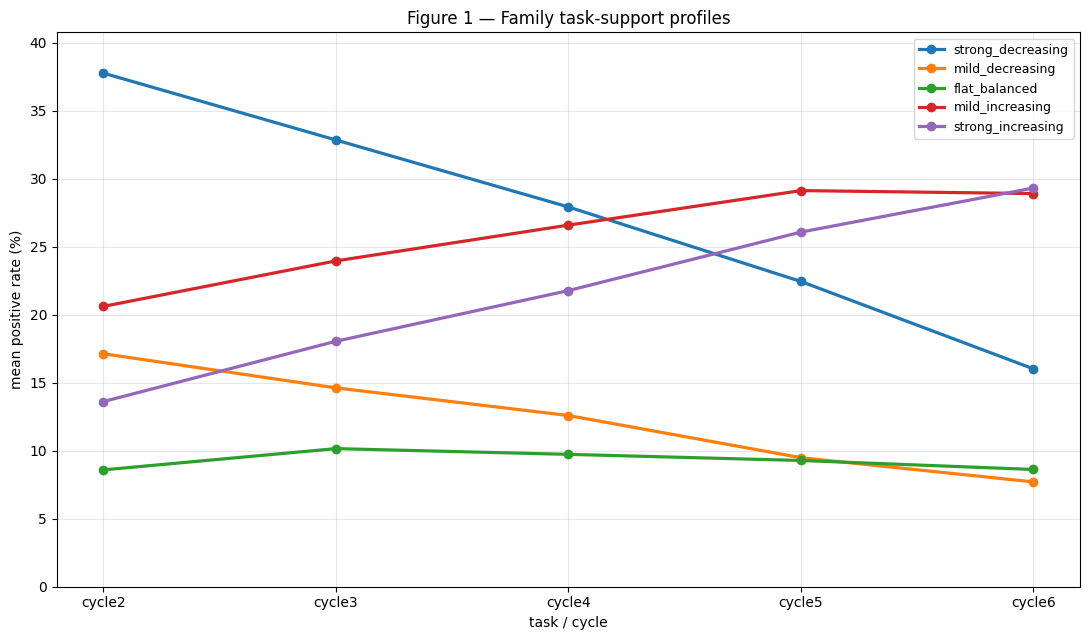

### Figure 2 — Overall benchmark comparison

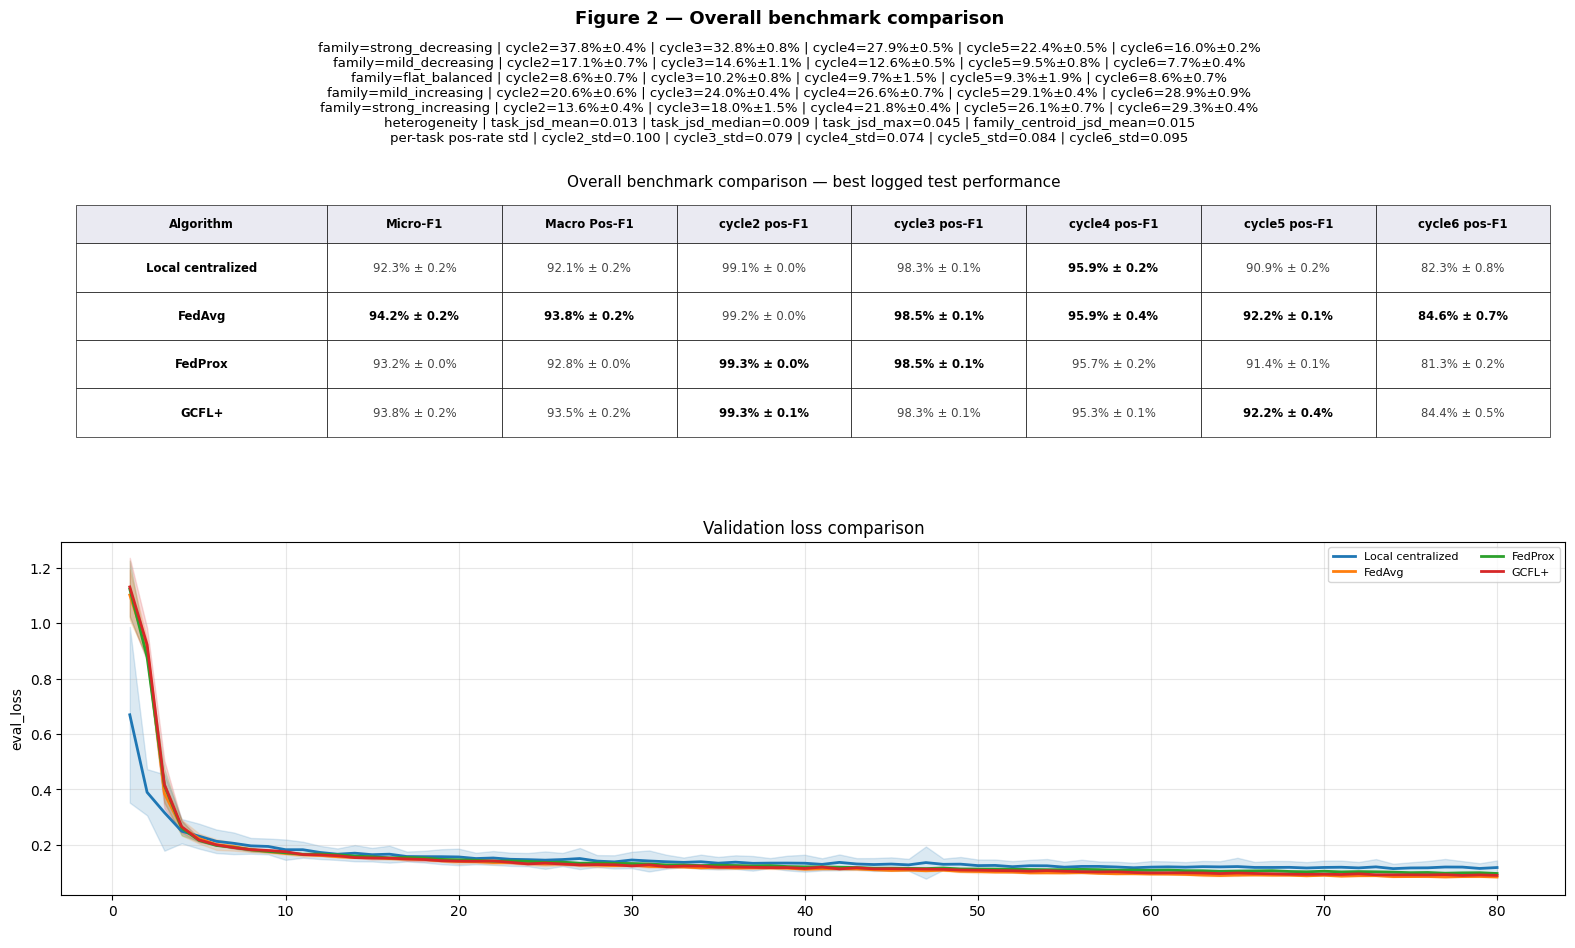

### Table 1 — Winner by regime

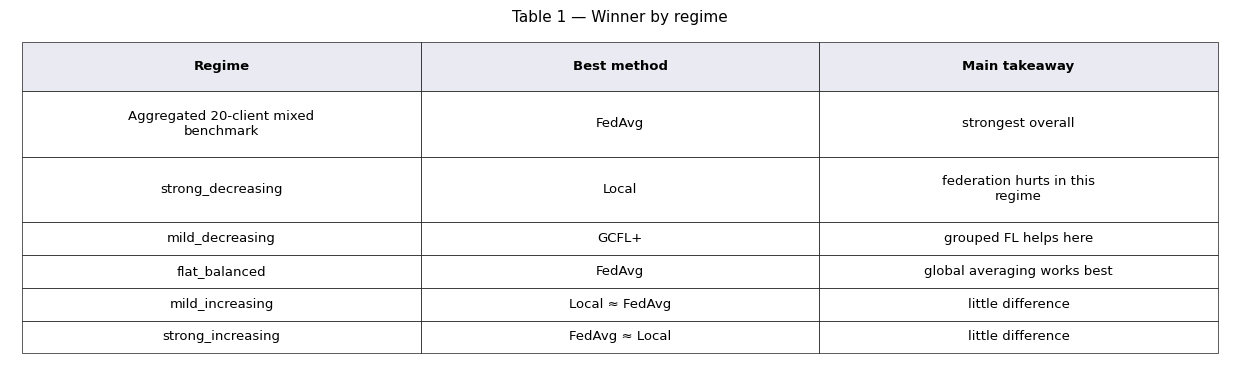

### Figure 3 — One family case where GCFL+ helps (mild_decreasing)

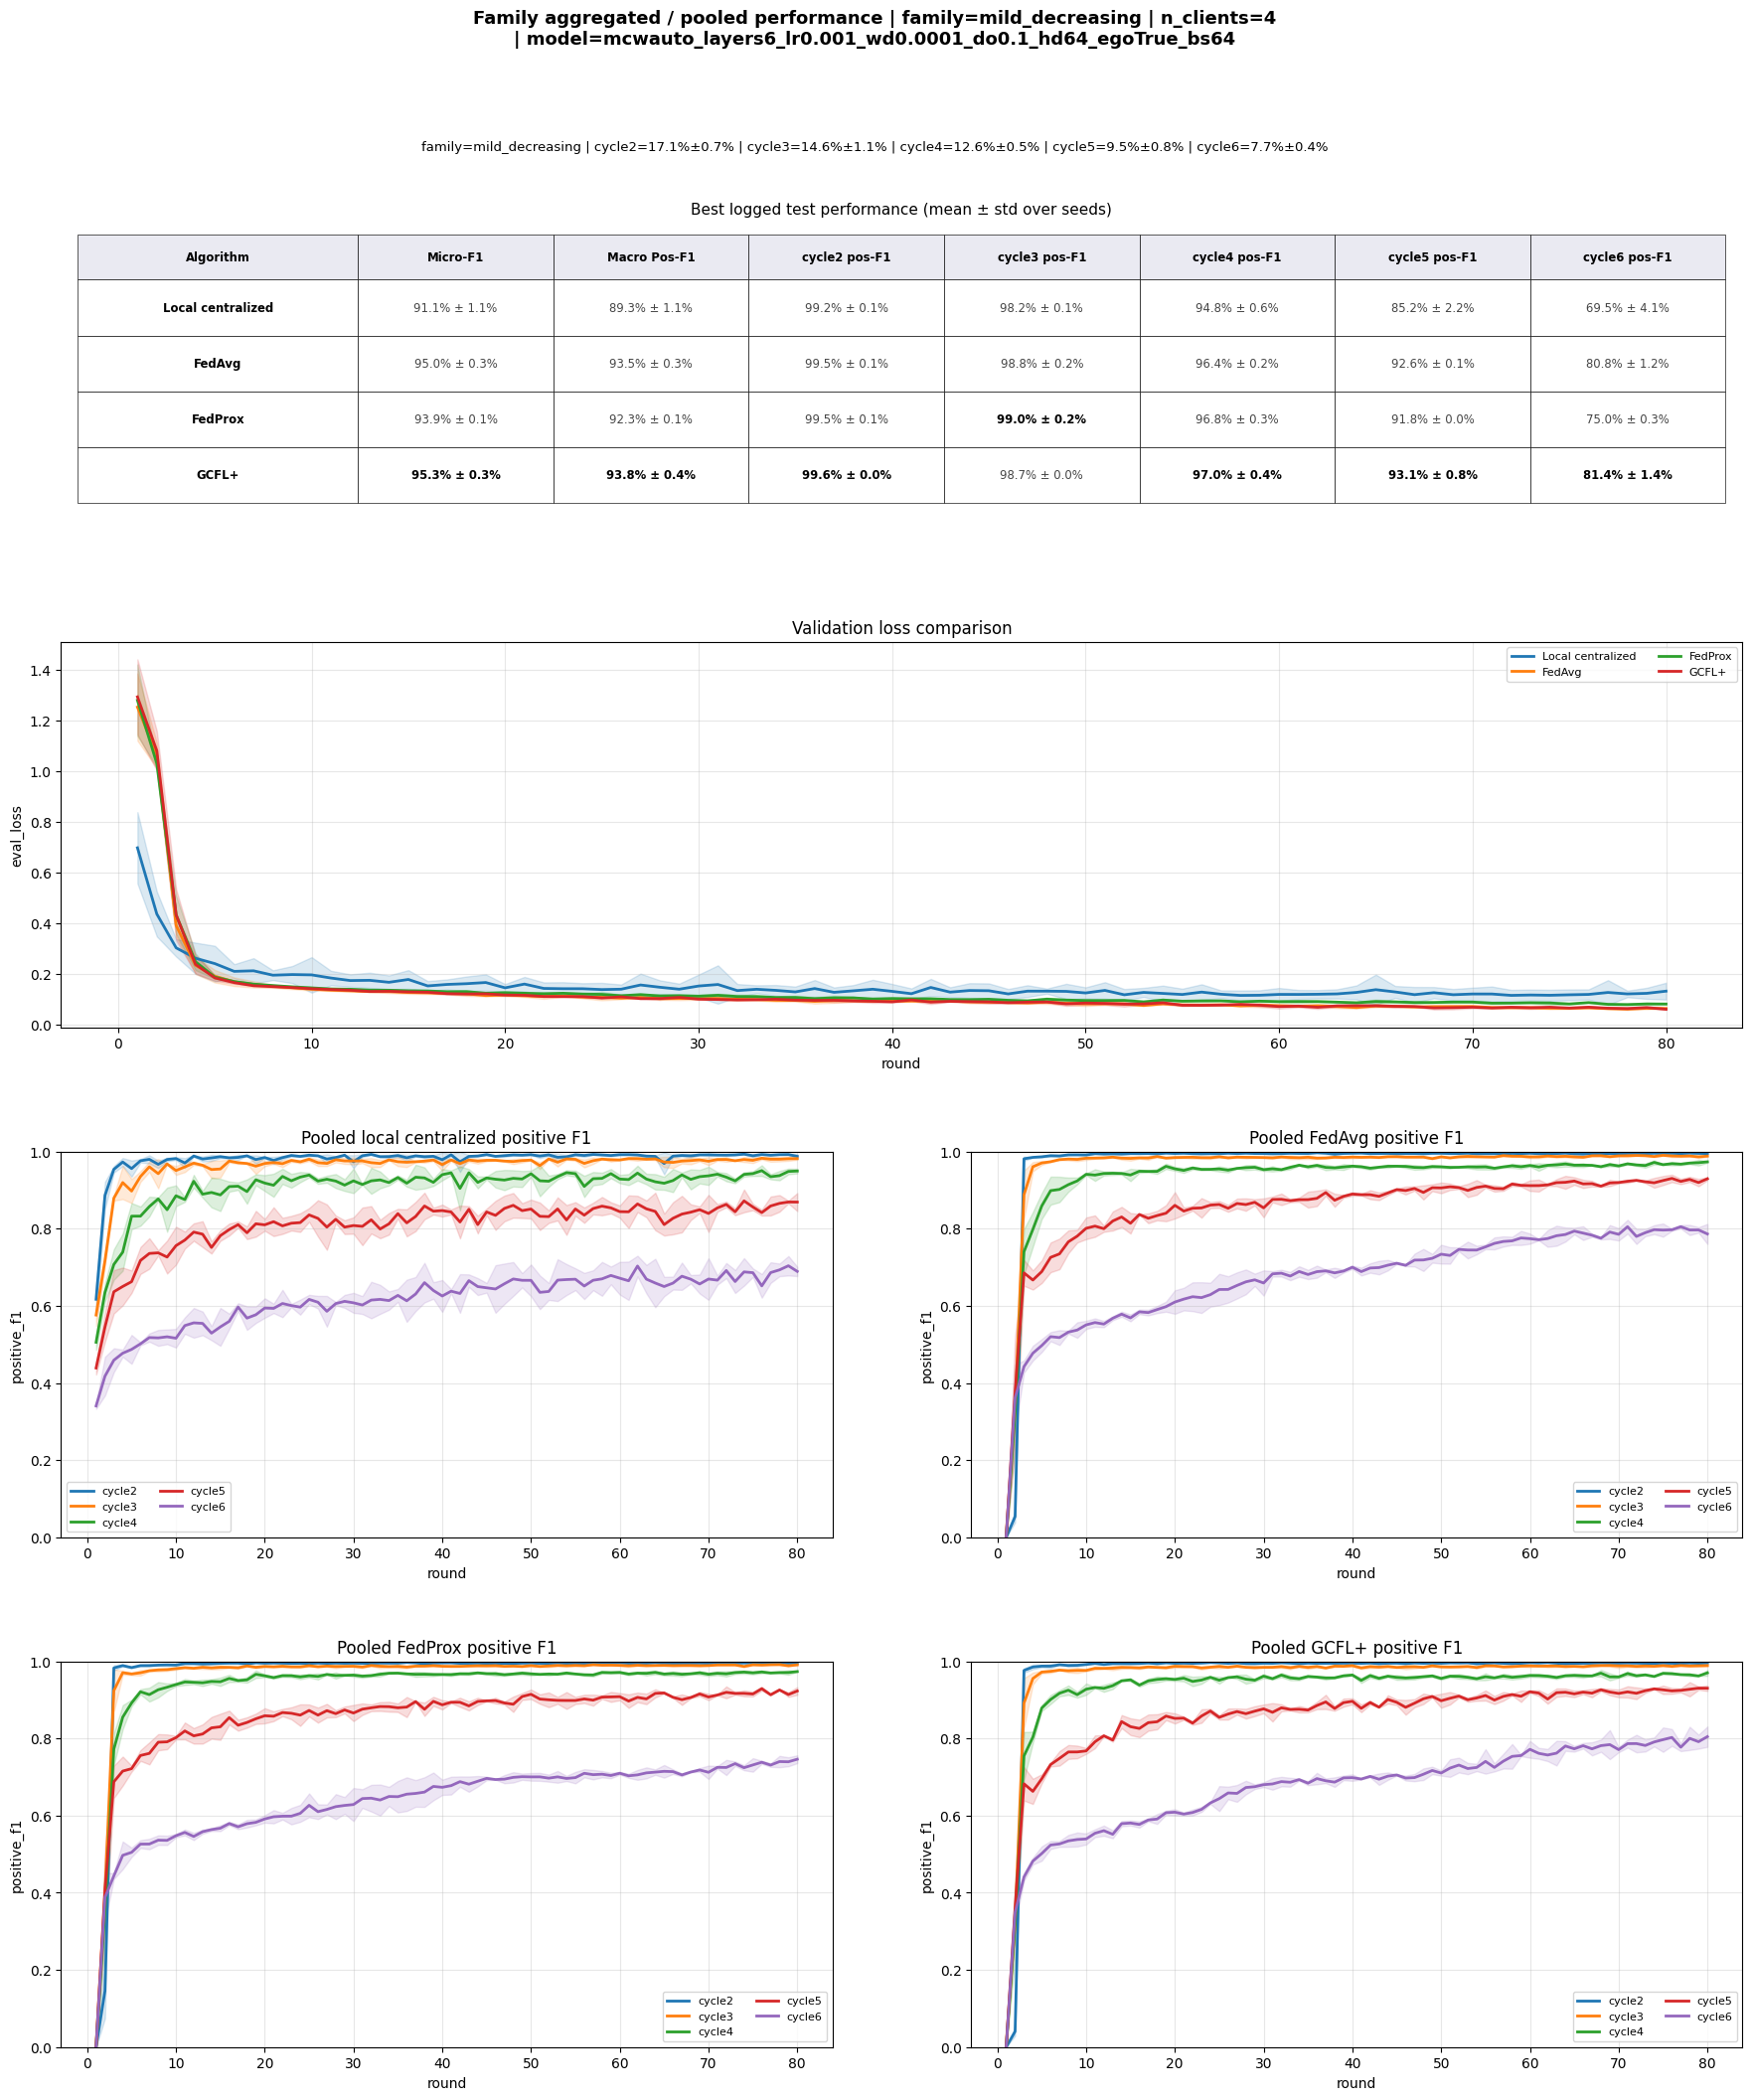

### Figure 4 — One family case where FedAvg helps (flat_balanced)

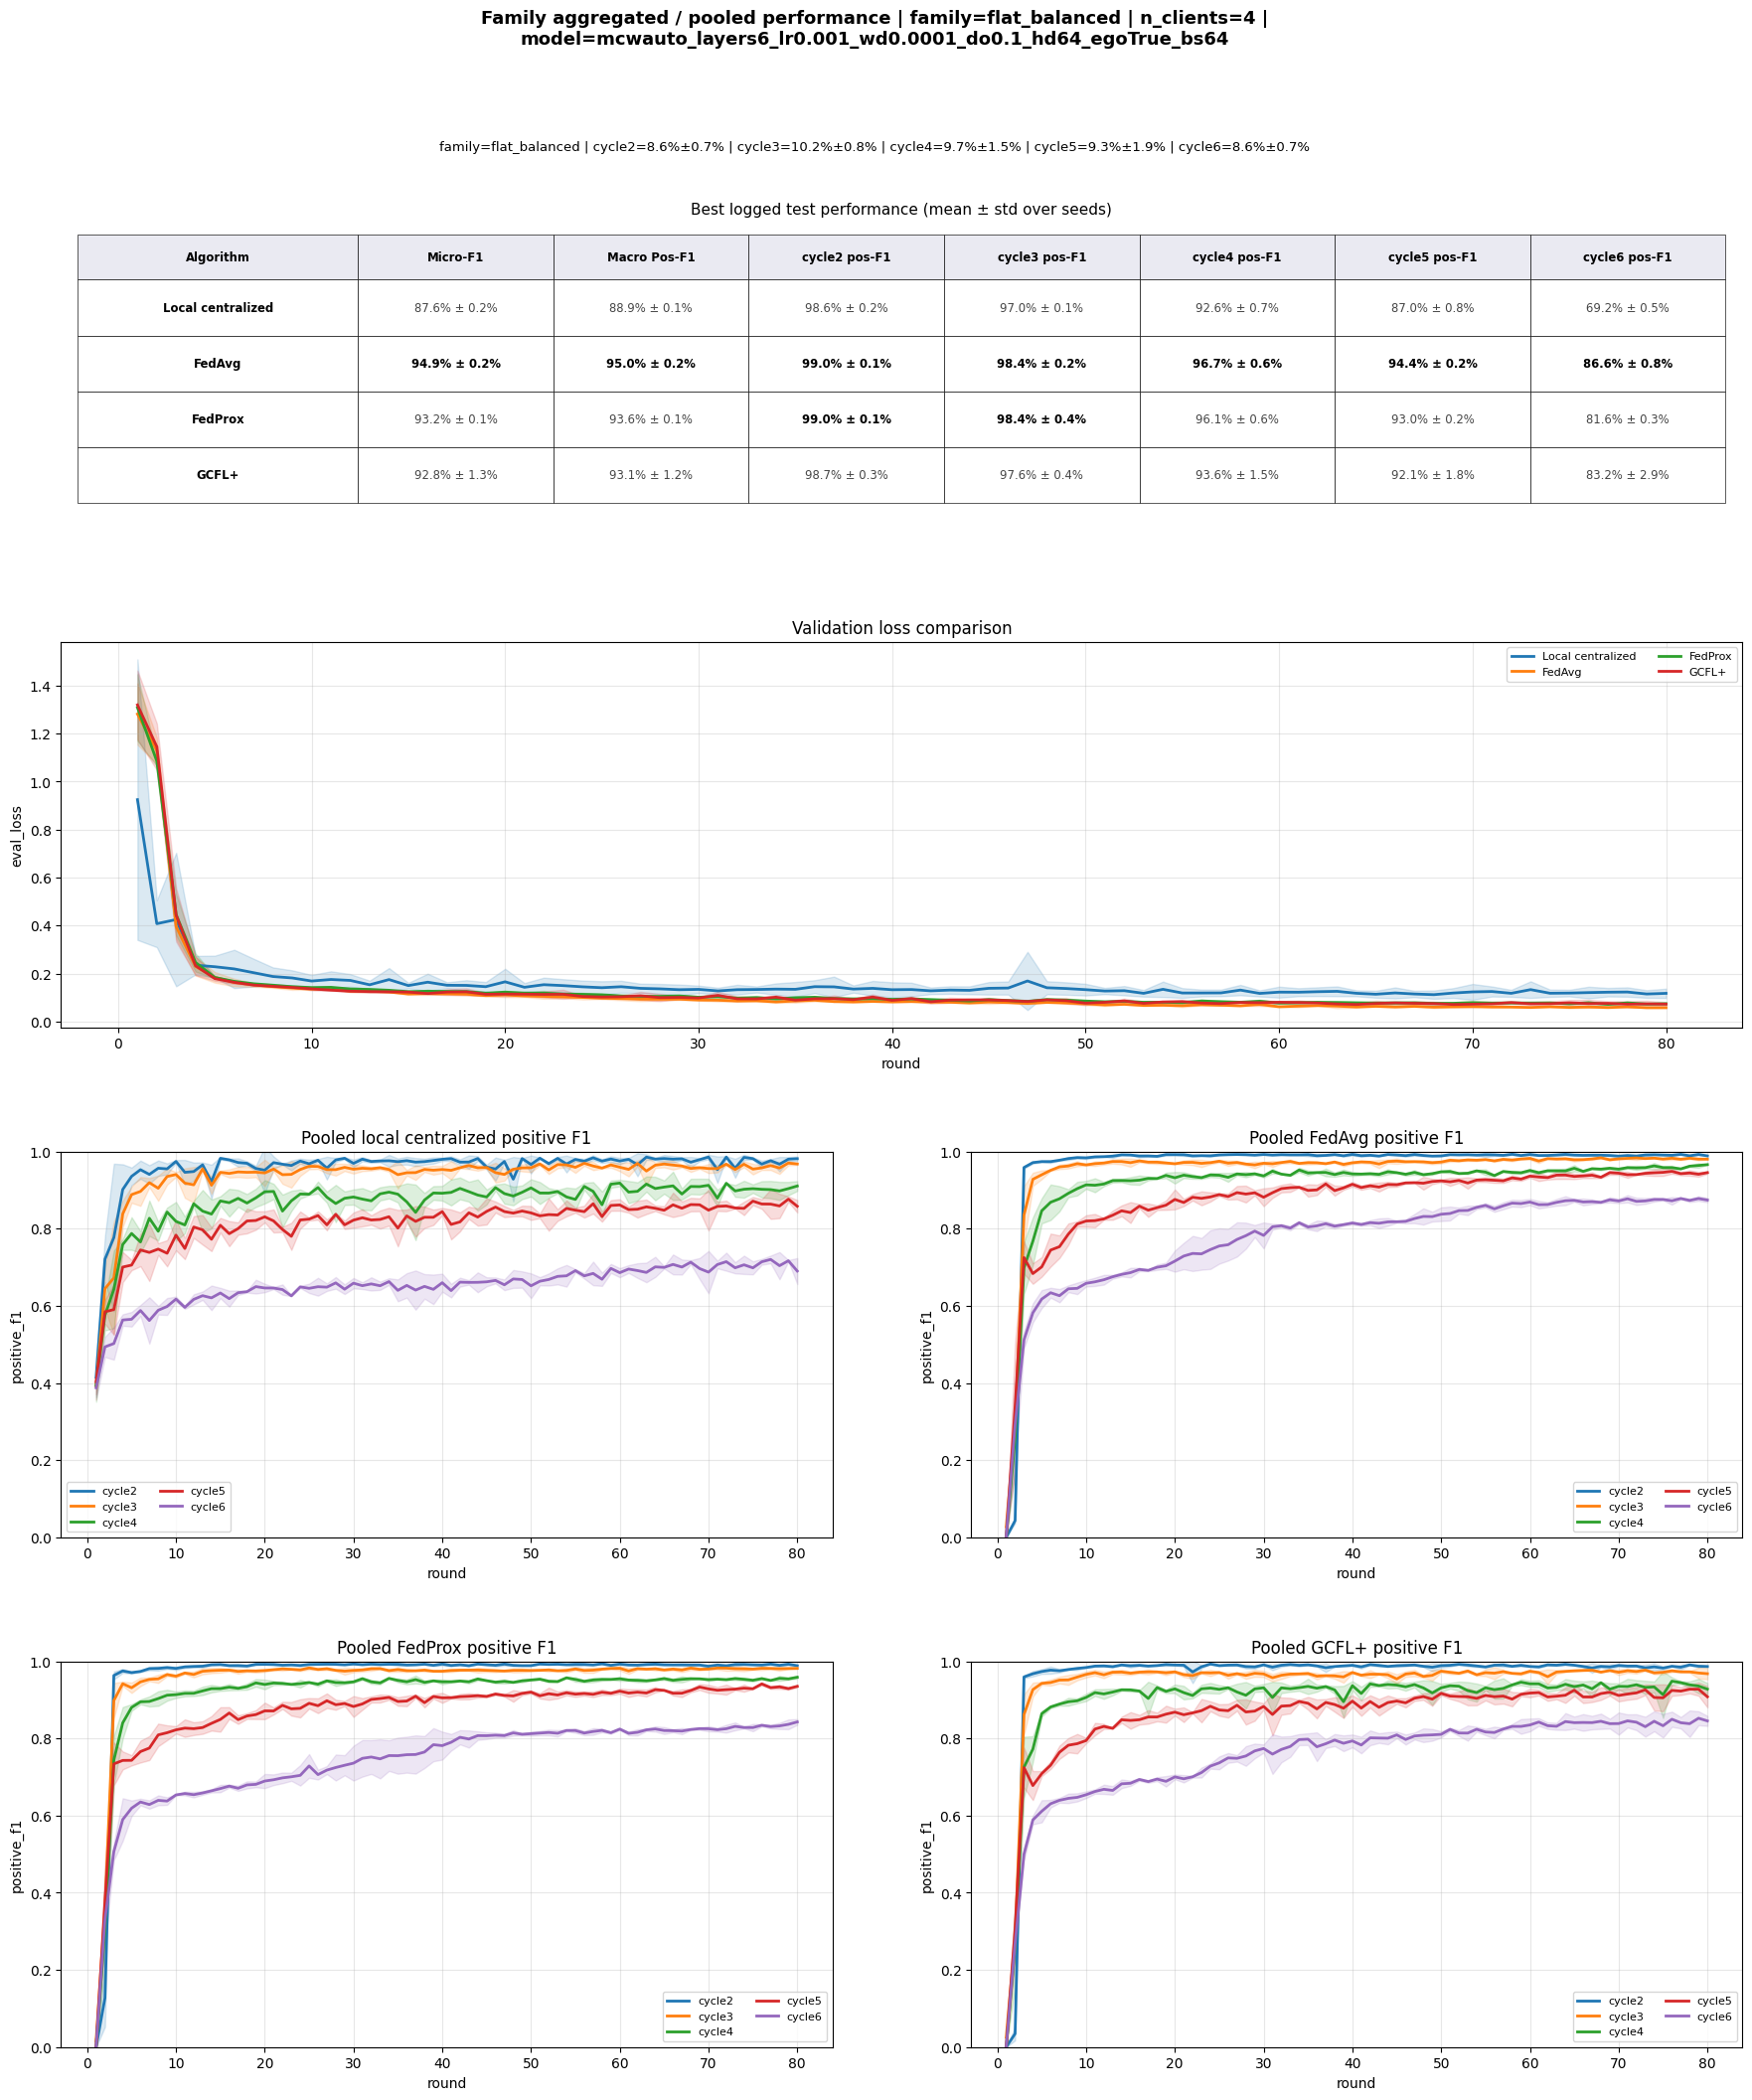

### Figure 5 — First applied split diagnostic

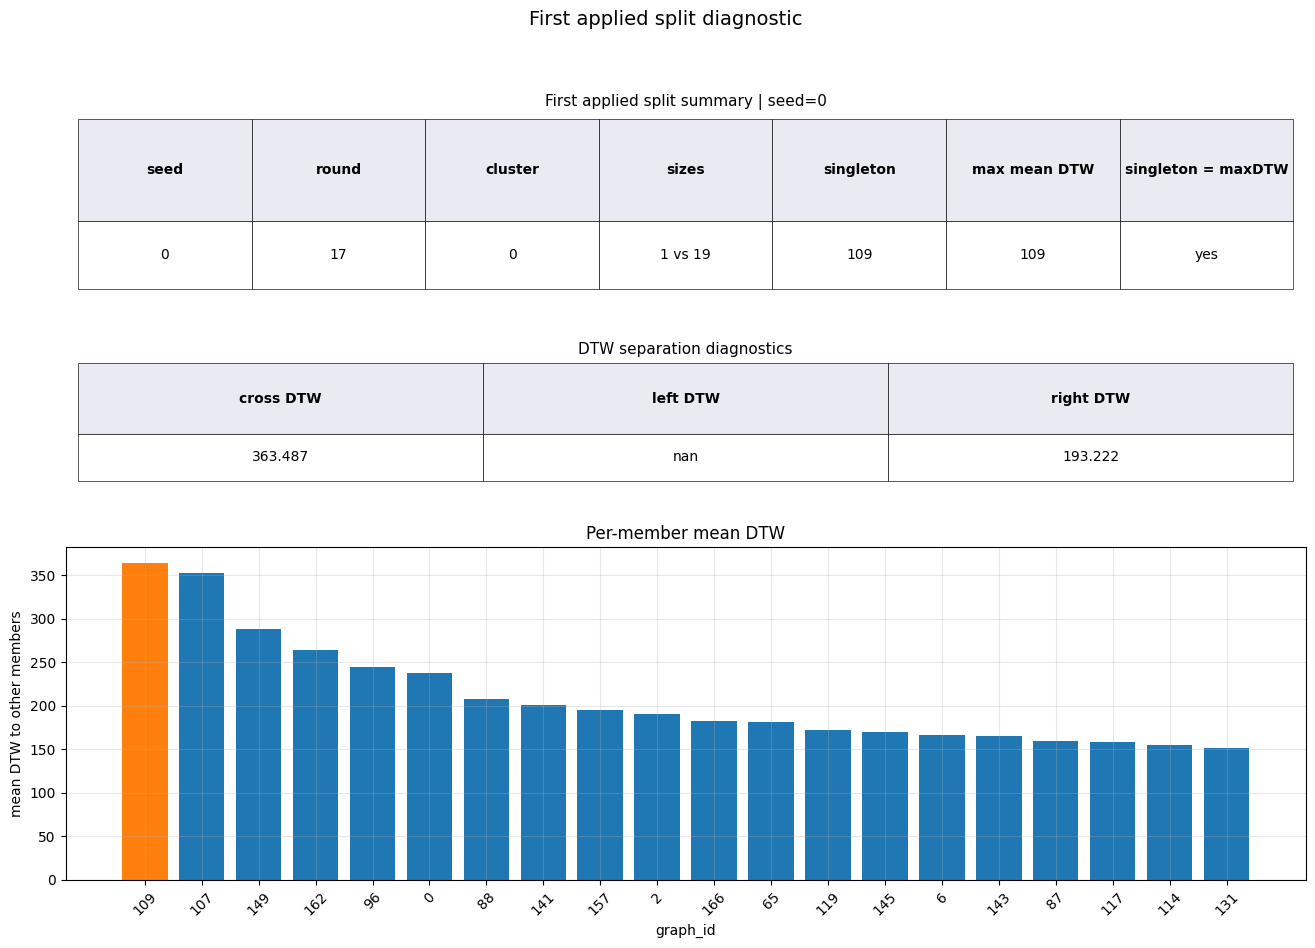

### Figure 6 — GCFL+ limitation / diagnostic

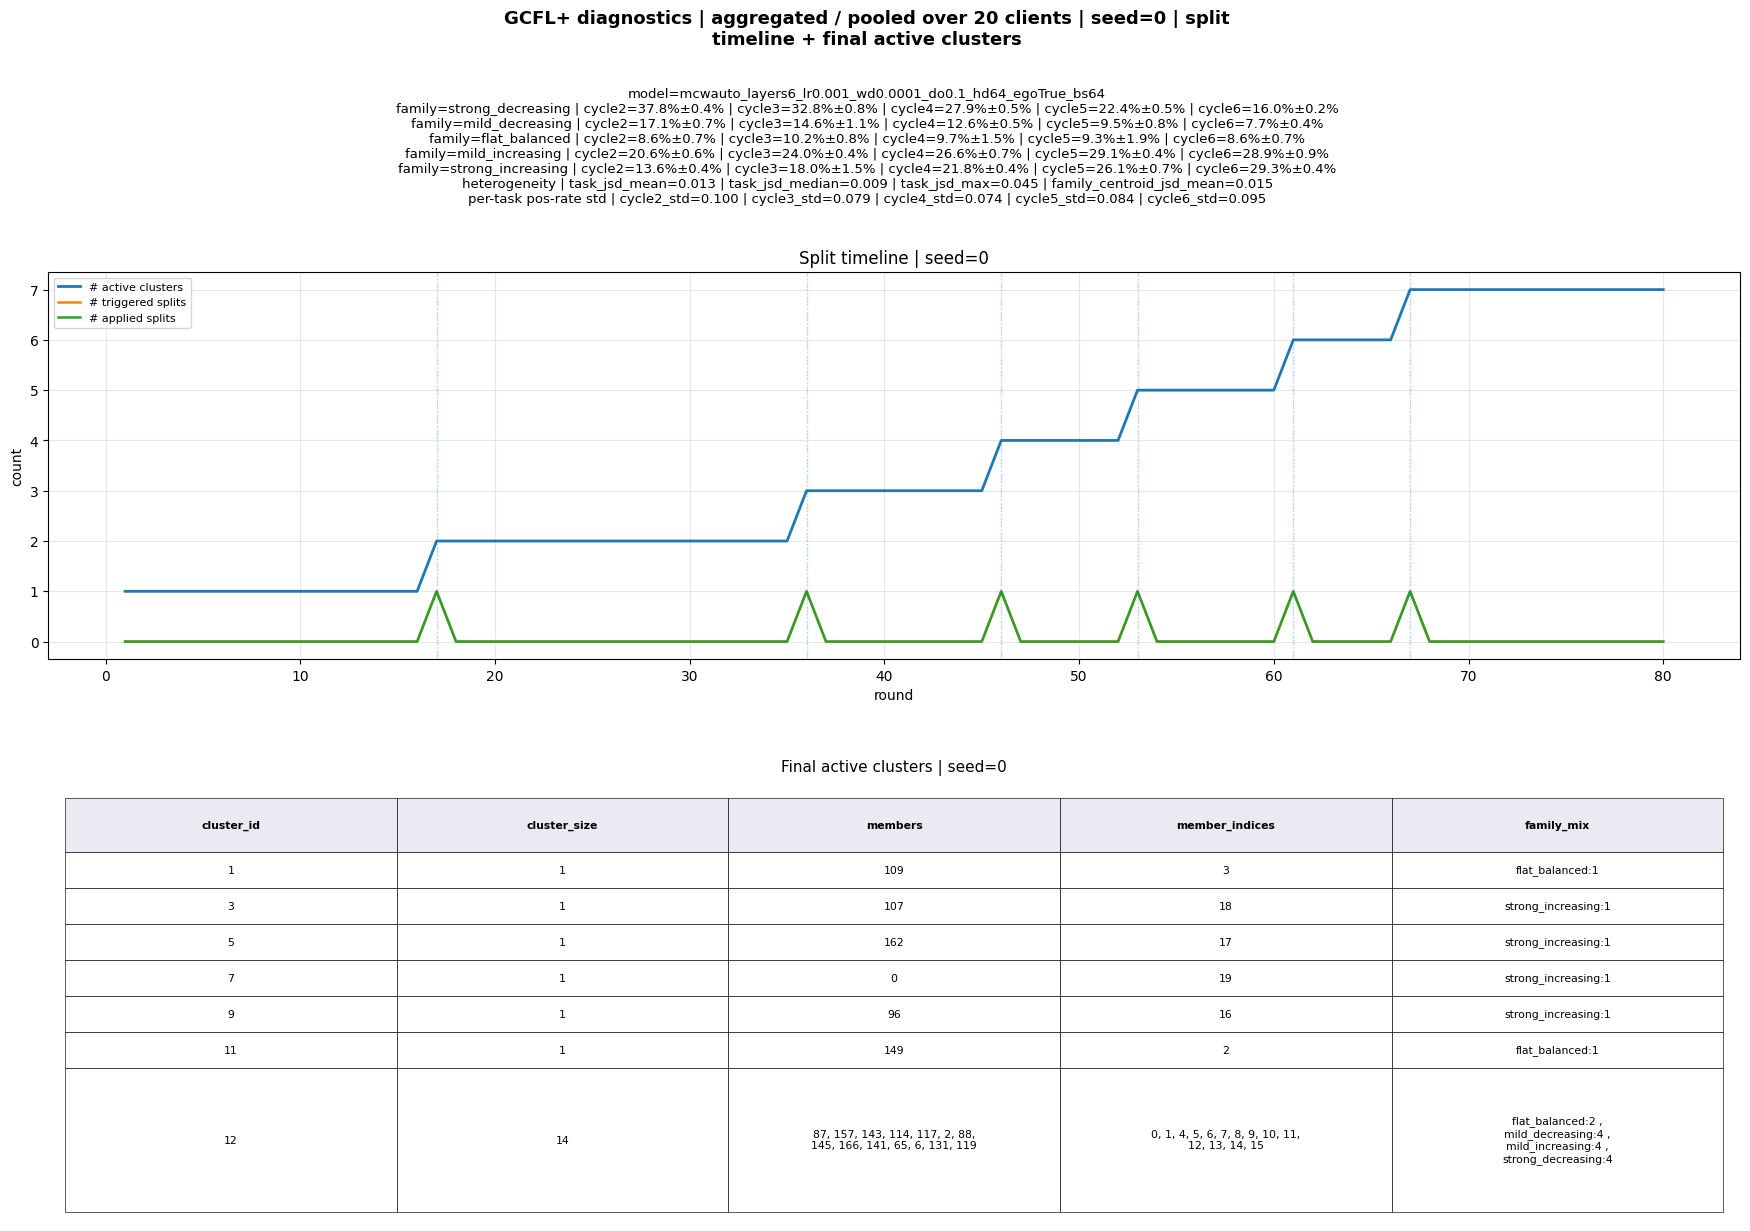

In [57]:
# focus only on local_epochs == 1
global_run_table = build_global_run_table(
    selected_subset,
    exp_log,
    methods=["fedavg", "fedprox", "gcfl_plus"],
    local_epochs=1,
)

family_run_table = build_family_run_table(
    selected_subset,
    exp_log,
    methods=["fedavg", "fedprox", "gcfl_plus"],
    local_epochs=1,
)

display_requested_report_figures(
    global_run_table=global_run_table,
    family_run_table=family_run_table,
    exp_log=exp_log,
    test_gen=test_gen,
    gcfl_seed=0,
    include_gcfl_final_table=True,
)